<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/Proyecto-261554/Modelo_Avance_Proyecto_2do_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avance del Proyecto

[Análisis de la Encuesta Nacional sobre Salud Financiera (ENSAFI)]


**Etapas: Métricas de Calidad de los Datos, Análisis Descriptivo y Preprocesamiento y EDA**

Nombre: [Juan Francisco Gámez Cortés]

Matrícula: 261554

Fecha: [29/09/2025]

## 1) Introducción
- Descripción breve del problema que se pretende abordar.

  En México, la salud financiera de la población adulta enfrenta retos significativos derivados de factores como ingresos insuficientes, endeudamiento, falta de educación financiera y la inestabilidad del entorno económico. Estas condiciones generan un impacto directo en el bienestar de las personas, manifestándose en dificultades para cubrir necesidades básicas, limitaciones en la capacidad de ahorro e inversión, así como en niveles elevados de preocupación y estrés financiero.

  
- Objetivo general del proyecto y objetivos específicos.

  Comprender los aspectos determinantes de la salud financiera de la población mexicana de 18 años y más, a fin de conocer de manera integral los elementos que conforman su estabilidad económica.
  Se busca identificar cómo las dificultades financieras inciden en la calidad de vida, cuáles son las preocupaciones más recurrentes en torno a la gestión de los recursos personales y en qué medida estas condiciones se relacionan con el nivel de estrés reportado por la población.

- Contexto del dataset en relación con el problema planteado.

  El dataset empleado en este proyecto corresponde a información recopilada a través de la ENSAFI, la cual es una encuesta representativa de la población mexicana de 18 años y más, elaborada por INEGI en colaboración con CONDUSEF. Dicho conjunto de datos integra por cuatro tablas que observan variables sociodemográficas (edad, sexo, nivel educativo, ocupación), económicas (ingresos, gastos, ahorro, endeudamiento) y percepciones subjetivas relacionadas con la situación financiera (preocupaciones, expectativas y nivel de estrés).


In [1]:
#Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2) Descripción del dataset
### Fuente de los datos.

  INEGI - ENSAFI 2023
  
  https://www.inegi.org.mx/programas/ensafi/2023/#datos_abiertos

###Variables principales de interés.

* Ahorro, deuda, gasto.

* Indicador de Bienestar Financiero: para medir la salud financiera. Es una puntuación integral que resume la percepción de una persona sobre su seguridad, resiliencia y libertad financiera.

* Indicador de Estrés Financiero: Mide directamente el nivel de preocupación y estrés. Es una puntuación de para cuantificar qué tan recurrentes son las preocupaciones en la población.

* Nivel de Deuda: Indica si una persona tiene deudas (formales o informales) y su percepción sobre el nivel de endeudamiento (si lo considera bajo, moderado, alto o excesivo).

* Ahorro: Indica si la persona ahorra y cuánto representa ese ahorro en relación con su ingreso, es decir, la capacidad de ahorro.

* Sexo, Edad y Entidad: para segmentar la población y descubrir qué grupos son más vulnerables

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.weightstats import DescrStatsW
import matplotlib.ticker as ticker
from typing import Dict, Optional, Tuple
from scipy.stats import norm, skew, kurtosis

###Número de registros y variables.
  * Tabla VIVIENDA: Dimensiones (20201, 36)
  * Tabla HOGAR: Dimensiones (20448, 55)
  * Tabla SDEM: Dimensiones (67781, 25)
  * Tabla MODULO: Dimensiones (20448, 253)

####Tabla VIVIENDA

* Características de la vivienda

  Información sobre el número de cuartos que se usan para dormir, el número de baños completos, los bienes y servicios del hogar, así como la situación de la vivienda, a través de variables sobre tenencia de la vivienda, escritura o título, adquisición, financiamiento, deuda y mensualidades vencidas de la vivienda.

In [4]:
# Leer el archivo de la Tabla de características de la Vivienda
dfTV = pd.read_csv('/content/drive/MyDrive/Proyecto/TVIVIENDA.csv')

# Validar que el dataset se cargo adecuadamente
print(dfTV.head())
print(dfTV.info())
print("Dimensiones:", dfTV.shape)

   LLAVEVIV  P1_1  P1_2  P1_3  P1_4_01  P1_4_02  P1_4_03  P1_4_04  P1_4_05  \
0  76010703     2     4     1        1        2        2        2        2   
1  76010704     3     3     1        1        1        2        1        2   
2  76010705     2     2     1        2        1        2        2        2   
3  76010706     2     3     1        1        1        2        2        2   
4  76010707     1     3     1        1        2        2        2        2   

   P1_4_06  ...  P2_3     UPM  VIV_SEL  ENT  MUN  TLOC  REGION  FAC_VIV  \
0        2  ...   NaN  760107        3    7   27     4       4     2313   
1        2  ...   NaN  760107        4    7   27     4       4     2313   
2        2  ...   NaN  760107        5    7   27     4       4     2313   
3        2  ...   NaN  760107        6    7   27     4       4     2313   
4        2  ...   NaN  760107        7    7   27     4       4     2313   

   UPM_DIS  EST_DIS  
0      631       52  
1      631       52  
2      631    

#### Tabla HOGAR
* Características sociodemográficas del Hogar

  Información económica y financiera que involucra a todas las personas que integran el hogar. En principio, se indaga sobre los ingresos que obtienen de otras fuentes diferentes al trabajo, además, y por medio de autollenado, se pregunta por los ingresos que provienen de la actividad
  laboral; después se indaga sobre la tenencia de cuentas bancarias y de Afores, sobre los tipos de créditos adquiridos, hábitos de ahorro, condición de deuda y si han tenido atrasos en sus pagos, así como la toma de decisiones en el hogar y conocer si tuvieron algún tipo de privación económica.

In [5]:
# Leer el archivo de la Tabla de características del Hogar
dfTH = pd.read_csv('/content/drive/MyDrive/Proyecto/THOGAR.csv')

# Validar que el dataset se cargo adecuadamente
print(dfTH.head())
print(dfTH.info())
print("Dimensiones:", dfTH.shape)

    LLAVEHOG  LLAVEVIV  P4_1_1  P4_1_2  P4_1_3  P4_1_4  P4_1_5  P4_1_6  \
0  505941161  50594116       1       1       2       2       2       2   
1  505941171  50594117       2       1       2       2       2       2   
2  505941181  50594118       2       2       2       2       2       2   
3  505941191  50594119       1       1       2       2       2       2   
4  505941201  50594120       2       2       2       2       2       2   

   P4_1_7  P4_1_8  ...     UPM  VIV_SEL  HOGAR  ENT  MUN  TLOC  REGION  \
0       2       2  ...  505941       16      1    5   24     2       1   
1       2       2  ...  505941       17      1    5   24     2       1   
2       2       2  ...  505941       18      1    5   24     2       1   
3       2       2  ...  505941       19      1    5   24     2       1   
4       2       2  ...  505941       20      1    5   24     2       1   

   FAC_HOG  UPM_DIS  EST_DIS  
0     1020      397       35  
1     1020      397       35  
2     1020      3

#### Tabla SDEM
* Características sociodemográficas de las personas del hogar

  Datos básicos de todas las personas que forman el hogar y con ello obtener el perfil sociodemográfico de todas ellas mediante
  las variables de parentesco, sexo, edad, asistencia escolar, escolaridad, condición de actividad económica y verificación de actividad económica. En el caso del cuestionario en papel, esta sección contiene una pregunta para elegir a la persona a la que se aplicó la entrevista individual; para el cuestionario electrónico, la selección se realizó de manera aleatoria.

In [6]:
# Leer el archivo de la Tabla de características Sociodemográficas
dfTS = pd.read_csv('/content/drive/MyDrive/Proyecto/TSDEM.csv')

# Validar que el dataset se cargo adecuadamente
print(dfTS.head())
print(dfTS.info())
print("Dimensiones:", dfTS.shape)

      LLAVESDE  LLAVEVIV   LLAVEHOG  PAREN  SEXO  EDAD  P3_6_1  P3_6_2  \
0  30012203101  30012203  300122031      1     1    60     NaN     NaN   
1  30012204101  30012204  300122041      1     1    22     NaN     NaN   
2  30012205105  30012205  300122051      6     2    86     NaN     NaN   
3  30012205101  30012205  300122051      1     1    56     NaN     NaN   
4  30012205103  30012205  300122051      3     2    26     NaN     NaN   

   P3_6_3  P3_7  ...  VIV_SEL  HOGAR  N_REN  ENT  MUN  TLOC  REGION  FAC_HOG  \
0     1.0   NaN  ...        3      1      1    3    3     1       2      290   
1     2.0   2.0  ...        4      1      1    3    3     1       2      290   
2     2.0   NaN  ...        5      1      5    3    3     1       2      290   
3     2.0   NaN  ...        5      1      1    3    3     1       2      290   
4     2.0   2.0  ...        5      1      3    3    3     1       2      290   

   UPM_DIS  EST_DIS  
0      276       24  
1      276       24  
2      2

#### Tabla MODULO
* Características:
  * Personales y laborales
  * Deuda, ahorro y gasto individual
  * Comportamiento y percepciones del bienestar financiero
  * Estrés financiero
  * Metas financieras

  Información directa de la persona elegida, a fin de conocer sus características personales como etnicidad, discapacidad, estado conyugal y familiar, sus cargas financieras como dependientes económicos y pagos de la vivienda.
  
  Datos referentes al ahorro, y la manera en que acostumbran a hacerlo, sea informal o formal mediante los productos financieros disponibles.
  
  Información acerca de la organización de los ingresos y gastos personales, así como de los comportamientos de la persona informarte que se relacionan con su nivel de bienestar financiero.



In [7]:
# Leer el archivo de la Tabla de características Personales, Laborales, Deuda, Ahorro, Gasto,
# Conductas financieras, Factores Psicológicos y Estrés Financiero
dfTM = pd.read_csv('/content/drive/MyDrive/Proyecto/TMODULO.csv')

# Validar que el dataset se cargo adecuadamente
print(dfTM.head())
print(dfTM.info())
print("Dimensiones:", dfTM.shape)

      LLAVEMOD  LLAVEVIV   LLAVEHOG  EDAD_V  FILTRO_S5_1  P5_1  P5_2_1  \
0  20147503101  20147503  201475031      65            1     2       3   
1  20147504101  20147504  201475041      32            1     2       3   
2  20147505102  20147505  201475051      34            2     2       1   
3  20158102101  20158102  201581021      85            1     2       1   
4  20158103102  20158103  201581031      30            2     2       1   

   P5_2_2  P5_2_3  P5_2_4  ...  ORIEN_FUT  IMPULSIVID  ORIEN_ACCI  OPTIMISMO  \
0       1       2       3  ...          1           2           1          1   
1       1       1       1  ...          2           2           1          1   
2       1       1       1  ...          2           1           1          1   
3       1       2       2  ...          2           2           1          1   
4       1       1       1  ...          1           2           1          1   

   GTOS_AHORR  DEPEN_SUM  DEP_ECO  FAC_ELE  UPM_DIS  EST_DIS  
0          

### Limitaciones del dataset.

Complejidad en la unión para realizar un análisis completo (ej. relacionar el estrés financiero de una persona con el ingreso total de su hogar), es indispensable unir estas tablas. Este proceso requiere identificar las variables clave correctas.

Nombres de variables codificados, se requiere consultar el diccionario de datos para entender el significado de cada columna.

Para interpretar las respuestas se requiere recodificar los valores numericos a sus correspondientes valores categoricos.



## 3) Preguntas de análisis descriptivo

Formular al menos tres preguntas directamente relacionadas con el problema del proyecto.

- ¿Cuál es la distribución Ponderada de la Deuda de la Vivienda?
- ¿Cuál es la distribución del ingreso total mensual de los hogares?
- ¿Cuál es la distribución de hogares según el rango de ingresos mensuales?
- ¿Cuáles son las principales fuentes de deuda en los hogares mexicanos?
- ¿Cuáles son los principales tipos de ahorro en los hogares?


PARA ANÁLISIS POSTERIORES

- ¿Cómo se distribuyen las puntuaciones del Indicador de Bienestar Financiero?
- ¿Qué porcentaje de la población con un nivel de estrés financiero alto reporta no tener ahorros?
- ¿Qué porcentaje de personas, según su nivel de ahorro (sin ahorro, hasta una quincena, más de un mes) elegiría "usar sus ahorros" como principal estrategia para afrontar un gasto imprevisto?
- ¿Qué porcentaje de las personas que perciben su nivel de deuda como "alto" o "excesivo" reportaron haberse atrasado en algún pago?

## 4) Métricas de calidad de los datos
* Identificación de:
  * Datos faltantes por diseño
  * Valores duplicados
  * Tipos de datos

### TABLA VIVIENDA

In [8]:
# Valores faltantes por diseño Vivienda
v_missing_values_by_desing = dfTV.isnull().sum()
print("Datos faltantes por diseño: \n",v_missing_values_by_desing[v_missing_values_by_desing > 0])

# Duplicados
print("\nDatos duplicados: \n",dfTV.duplicated().sum())

# Tipos de datos
print("\nTipos de Datos:\n",dfTV.dtypes)

Datos faltantes por diseño: 
 P1_6       6333
P1_7       6333
P1_8_1     8145
P1_8_2     8145
P1_8_3     8145
P1_8_4     8145
P1_8_5     8145
P1_9      15966
P1_10     18313
P2_3      19988
dtype: int64

Datos duplicados: 
 0

Tipos de Datos:
 LLAVEVIV      int64
P1_1          int64
P1_2          int64
P1_3          int64
P1_4_01       int64
P1_4_02       int64
P1_4_03       int64
P1_4_04       int64
P1_4_05       int64
P1_4_06       int64
P1_4_07       int64
P1_4_08       int64
P1_4_09       int64
P1_4_10       int64
P1_5          int64
P1_6        float64
P1_7        float64
P1_8_1      float64
P1_8_2      float64
P1_8_3      float64
P1_8_4      float64
P1_8_5      float64
P1_9        float64
P1_10       float64
P2_1          int64
P2_2          int64
P2_3        float64
UPM           int64
VIV_SEL       int64
ENT           int64
MUN           int64
TLOC          int64
REGION        int64
FAC_VIV       int64
UPM_DIS       int64
EST_DIS       int64
dtype: object


### TABLA HOGAR

In [9]:
# Valores faltantes por diseño Hogar
h_missing_values_by_desing = dfTH.isnull().sum()
print("Datos faltantes por diseño: \n",h_missing_values_by_desing[h_missing_values_by_desing > 0])

# Duplicados
print("\nDatos duplicados: \n",dfTH.duplicated().sum())

# Tipos de datos
print("\nTipos de Datos:\n",dfTH.dtypes)

Datos faltantes por diseño: 
 P4_4_1     3107
P4_4_2     3107
P4_5_1     3107
P4_5_2     3107
P4_5_3     3107
P4_5_4     3107
P4_6_1     3107
P4_6_2     3107
P4_6_3     3107
P4_6_4     3107
P4_6_5     3107
P4_7_1     3107
P4_8_1    15551
P4_7_2     3107
P4_8_2    19526
P4_7_3     3107
P4_8_3    20049
P4_7_4     3107
P4_8_4    20094
P4_9_1     3107
P4_9_2     3107
P4_9_3     3107
P4_9_4     3107
P4_9_5     3107
P4_9_6     3107
dtype: int64

Datos duplicados: 
 0

Tipos de Datos:
 LLAVEHOG         int64
LLAVEVIV         int64
P4_1_1           int64
P4_1_2           int64
P4_1_3           int64
P4_1_4           int64
P4_1_5           int64
P4_1_6           int64
P4_1_7           int64
P4_1_8           int64
P4_1_9           int64
P4_2             int64
P4_3             int64
FILTRO_S4_1      int64
P4_4_1         float64
P4_4_2         float64
P4_5_1         float64
P4_5_2         float64
P4_5_3         float64
P4_5_4         float64
P4_6_1         float64
P4_6_2         float64
P4_6_3    

### TABLA SDEM

In [10]:
# Valores faltantes por diseño SDEM
s_missing_values_by_desing = dfTS.isnull().sum()
print("Datos faltantes por diseño: \n",s_missing_values_by_desing[s_missing_values_by_desing > 0])

# Duplicados
print("\nDatos duplicados: \n",dfTS.duplicated().sum())

# Tipos de datos
print("\nTipos de Datos:\n",dfTS.dtypes)

Datos faltantes por diseño: 
 P3_6_1    64758
P3_6_2    64758
P3_6_3    19395
P3_7      38483
NIV        2324
GRA        2324
P3_9      11994
P3_10     44978
dtype: int64

Datos duplicados: 
 0

Tipos de Datos:
 LLAVESDE      int64
LLAVEVIV      int64
LLAVEHOG      int64
PAREN         int64
SEXO          int64
EDAD          int64
P3_6_1      float64
P3_6_2      float64
P3_6_3      float64
P3_7        float64
NIV         float64
GRA         float64
P3_9        float64
P3_10       float64
UPM           int64
VIV_SEL       int64
HOGAR         int64
N_REN         int64
ENT           int64
MUN           int64
TLOC          int64
REGION        int64
FAC_HOG       int64
UPM_DIS       int64
EST_DIS       int64
dtype: object


### TABLA MODULO

In [11]:
# Valores faltantes por diseño Modulo
m_missing_values_by_desing = dfTM.isnull().sum()
print("Datos faltantes por diseño: \n",m_missing_values_by_desing[m_missing_values_by_desing > 0])

# Duplicados
print("\nDatos duplicados: \n",dfTM.duplicated().sum())

# Tipos de datos
print("\nTipos de Datos:\n",dfTM.dtypes)

Datos faltantes por diseño: 
 P5_4           8917
P5_4A          9911
P5_6          13293
P5_8           4853
P5_9_1         4853
              ...  
P10_2         14982
P10_3         14982
INGRESO_M      6744
SAL_MIN_RP     7712
SAL_MIN_ZF    19480
Length: 83, dtype: int64

Datos duplicados: 
 0

Tipos de Datos:
 LLAVEMOD       int64
LLAVEVIV       int64
LLAVEHOG       int64
EDAD_V         int64
FILTRO_S5_1    int64
               ...  
DEPEN_SUM      int64
DEP_ECO        int64
FAC_ELE        int64
UPM_DIS        int64
EST_DIS        int64
Length: 253, dtype: object


# ANÁLISIS DESCRIPTIVO DE LOS DATOS

In [15]:
# Definición de la función Footer para datos del pie de los graficos
# =========================================================================

def footer(ax, question, mnemonic, base_desc, n_muestra, universe_expansion, source="INEGI. ENSAFI, 2023"):
    """
    Función para añadir anotaciones al pie de un gráfico,
    incluyendo fuente, base, pregunta y universo expandido.

    Argumentos:
        ax (matplotlib.axes.Axes): El objeto Axes del gráfico actual.
        question (str): El texto conceptual de la pregunta.
        mnemonic (str): El código o nemónico de la pregunta (ej. , P1_9).
        base_desc (str): Descripción de la población base (ej. Personas que respondieron la sección).
        n_muestra (int): Tamaño de la muestra (n) para ese cálculo.
        universe_expansion (int): Valor total del factor de expansión (FAC_VIV).
        source (str): Fuente de los datos (predeterminado: INEGI. ENSAFI, 2023).
    """

    # 1. Formato del texto de la anotación
    question_line = f"Pregunta ({mnemonic}): {question}"
    base_line = f"Base: {base_desc} (n = {n_muestra:,.0f} registros)"
    # Utilizamos el factor de expansión (FAC_VIV) para el universo poblacional
    universe_line = f"Universo Expandido: {universe_expansion:,.0f} personas de 18 años y más en México"

    footer_text = f"Fuente: {source}\n{question_line}\n{base_line}\n{universe_line}"

    # Posición del pie de página (parte inferior)
    plt.figtext(0.5, 0.00,
                footer_text,
                wrap=True,
                horizontalalignment='center',
                fontsize=9,
                color='gray',
                bbox={"facecolor": "lightgray", "alpha": 0.3, "pad": 5})

# Ajustes de estilo para Seaborn
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

### Distribución Ponderada de la Deuda de la Vivienda

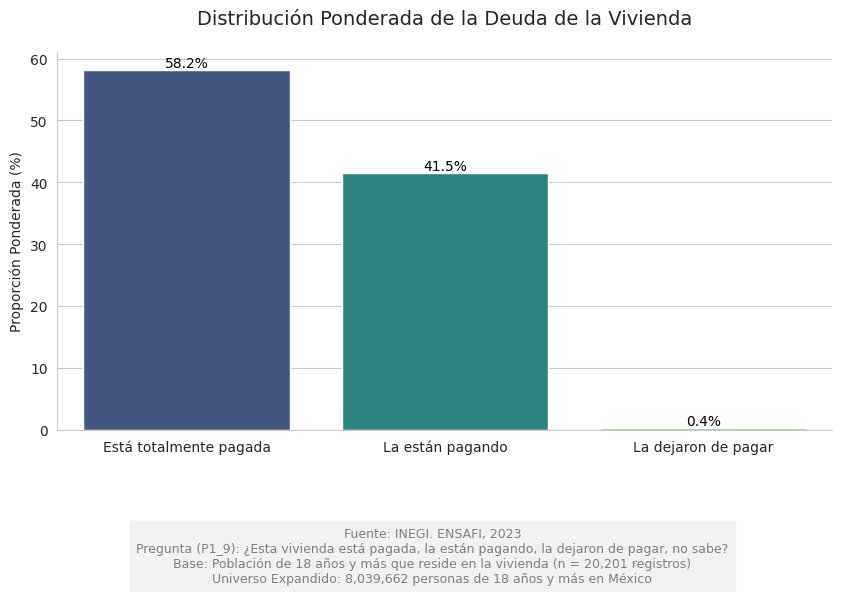

In [24]:
# Etiquetar la variable P1_9 (Deuda de la vivienda)
deuda_viv_map = {
    1: 'Está totalmente pagada',
    2: 'La están pagando',
    3: 'La dejaron de pagar',
    4: 'No sabe'
}
dfTV['Deuda_Label'] = dfTV['P1_9'].map(deuda_viv_map)

# Calcular Frecuencias Ponderadas
# Sumamos el factor de expansión para obtener el total poblacional por categoría
frecuencias_ponderadas = dfTV.groupby('Deuda_Label')['FAC_VIV'].sum()
#print(frecuencias_ponderadas)
# Calcular Proporciones
total_universo_expandido = frecuencias_ponderadas.sum()
proporciones = (frecuencias_ponderadas / total_universo_expandido) * 100

# Preparar df para la visualización
df_plot = proporciones.reset_index(name='Proporción')
n_efectivo = len(dfTV)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x='Deuda_Label',
            y='Proporción',
            hue='Deuda_Label',
            data=df_plot.sort_values(by='Proporción', ascending=False),
            palette='viridis',
            legend=False,
            ax=ax)

# Añadir etiquetas de porcentaje en las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

# Configuración del Título y Ejes
ax.set_title('Distribución Ponderada de la Deuda de la Vivienda', fontsize=14, pad=20)
ax.set_xlabel('')
ax.set_ylabel('Proporción Ponderada (%)')

# Eliminar el marco superior y derecho
sns.despine(top=True, right=True)

# Aplicar la función de anotación completa
footer(ax,
       question="¿Esta vivienda está pagada, la están pagando, la dejaron de pagar, no sabe?",
       mnemonic="P1_9",
       base_desc="Población de 18 años y más que reside en la vivienda",
       n_muestra=n_efectivo,
       universe_expansion=total_universo_expandido
      )

# Asegurar que el pie de página quepa en la figura
plt.subplots_adjust(bottom=0.25)
plt.show()

Estadísticas ponderadas del ingreso total mensual de los hogares

In [192]:
# Configuraciones de visualización para gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Función de Anotación
# ENSAFI 2023 cuya población base es de 18 años y más
# =========================================================================

def footer(ax, question_text, mnemonic, n_muestra, universe_expansion):
    """Añade anotaciones estandarizadas al pie del gráfico (footer)."""

    # La base es la población objetivo de la ENSAFI: 18 años y más
    base_desc = "Población de 18 años y más en México (registros válidos)"

    footer_text = (
        f"Fuente: INEGI. ENSAFI, 2023.\n"
        f"Pregunta ({mnemonic}): {question_text}\n"
        f"Base: {base_desc} (n = {n_muestra:,.0f} registros)\n"
        f"Universo Expandido: {universe_expansion:,.0f} hogares"
    )

    plt.figtext(0.5, 0.00,
                footer_text,
                wrap=True,
                horizontalalignment='center',
                fontsize=9,
                color='gray',
                bbox={"facecolor": "lightgray", "alpha": 0.3, "pad": 5})

# PREPROCESAMIENTO

# Limpieza de datos
# P4_2 tiene códigos especiales: 98000 ($98,000 y más) y 99999 (No sabe)

df_clean = dfTH[~dfTH['P4_2'].isin([98000, 99999])].copy()
df_clean = dfTH[dfTH['P4_2'] > 0].dropna(subset=['P4_2', 'FAC_HOG'])

# Definición del universo para el footer
n_efectivo = len(df_clean)
total_universo_expandido = df_clean['FAC_HOG'].sum()

# =========================================================================
# Análisis Descriptivo Ponderado (Uso de DescrStatsW)
# =========================================================================

variable_ingreso = df_clean['P4_2']
weights = df_clean['FAC_HOG']

# Instanciar DescrStatsW para estadísticas ponderadas
weighted_stats = DescrStatsW(data=variable_ingreso, weights=weights)

# Obtener estadísticas clave
weighted_mean = weighted_stats.mean
weighted_median = weighted_stats.quantile(0.5)
weighted_std = weighted_stats.std

print("Estadísticas Ponderadas del Ingreso Mensual del Hogar (P4_2)")
print(f"Media Ponderada: ${weighted_mean:,.2f}")
print(f"Mediana Ponderada: ${float(weighted_median.iloc[0]):,.2f}")
print(f"Desviación Estándar Ponderada: ${weighted_std:,.2f}")
print(f"Base (n): {n_efectivo:,.0f}")
print(f"Universo Expandido: {total_universo_expandido:,.0f} hogares")

Estadísticas Ponderadas del Ingreso Mensual del Hogar (P4_2)
Media Ponderada: $18,811.36
Mediana Ponderada: $8,300.00
Desviación Estándar Ponderada: $26,730.54
Base (n): 20,448
Universo Expandido: 38,669,271 hogares


### Histograma para visualizar la distribución de la variable P4_2 (Ingreso Total Mensual del hogar)
 -  ¿Cuál es la distribución del ingreso total mensual de los hogares?

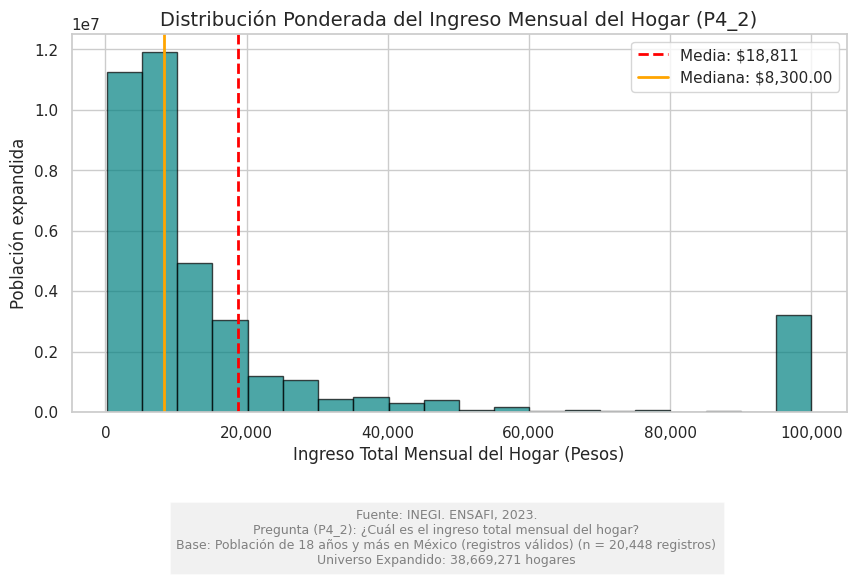

In [193]:
# Histograma Ponderado de P4_2 (Distribución de Ingresos)
fig, ax = plt.subplots(figsize=(10, 6))

# Calcular los pesos de frecuencia para el histograma:
# El histograma usa los pesos del factor de expansión (FAC_HOG)
ax.hist(df_clean['P4_2'],
        bins=20,
        weights=df_clean['FAC_HOG'],
        edgecolor='black',
        alpha=0.7,
        color='teal')

# Añadir líneas verticales para la Media y Mediana
ax.axvline(weighted_mean, color='red', linestyle='dashed', linewidth=2, label=f'Media: ${weighted_mean:,.0f}')
ax.axvline(weighted_median.iloc[0], color='orange', linestyle='solid', linewidth=2, label=f'Mediana: ${float(weighted_median.iloc[0]):,.2f}')

# Formatear el eje X para mostrar pesos en formato de pesos mexicanos
formatter = ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}')
ax.xaxis.set_major_formatter(formatter)

ax.set_title('Distribución Ponderada del Ingreso Mensual del Hogar (P4_2)', fontsize=14)
ax.set_xlabel('Ingreso Total Mensual del Hogar (Pesos)')

# El eje Y representa el total expandido de la población expandida
ax.set_ylabel('Población expandida')
ax.legend()

# Aplicar anotación completa
footer(ax,
       question_text="¿Cuál es el ingreso total mensual del hogar?",
       mnemonic="P4_2",
       n_muestra=n_efectivo,
       universe_expansion=total_universo_expandido
      )

plt.subplots_adjust(bottom=0.25)
plt.show()

Identificación de outliers del ingreso total mensual de los hogares

Usamos el criterio de Tukey o método del Rango Intercuartílico (IQR)  como técnica para la detección de outliers en la variable Ingreso Mensual del Hogar (P4_2)

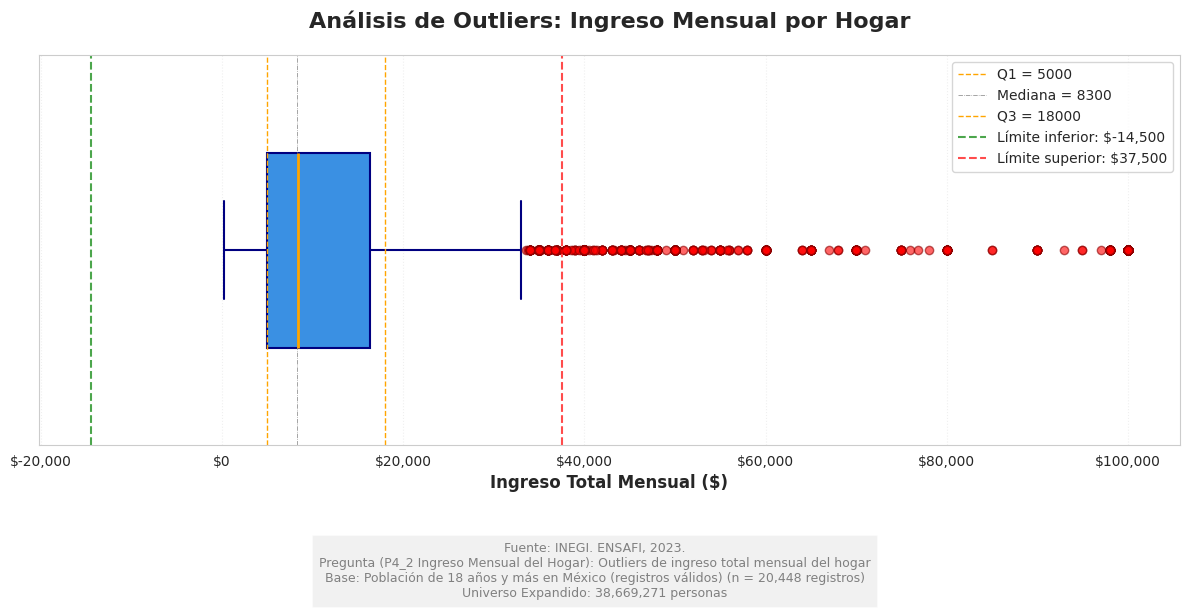

RESUMEN DE OUTLIERS (Criterio de Tukey)
Total de observaciones: 20,448
Outliers inferiores: 0
Outliers superiores: 2,347
Total de outliers: 2,347 (11.48%)
Rango normal: $-14,500 - $37,500
Rango de outliers superiores: > $37,500


In [64]:
#Establecer tamaño del gráfico
plt.figure(figsize=(12, 6))

# Calcular estadísticas para los outliers con criterio de Tukey IQR

weighted_mean = weighted_stats.mean
weighted_mean = weighted_stats.quantile(0.25)
weighted_std = weighted_stats.std

Q1 = float(weighted_stats.quantile(0.25).iloc[0])
Q3 = float(weighted_stats.quantile(0.75).iloc[0])
mediana = float(weighted_median.iloc[0])

IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Contabilizar los outliers
outliers_inferiores = (df_clean['P4_2'] < limite_inferior).sum()
outliers_superiores = (df_clean['P4_2'] > limite_superior).sum()
total_outliers = outliers_inferiores + outliers_superiores
porcentaje_outliers = (total_outliers / len(df_clean)) * 100

# Crear el boxplot de ingresos mensuales del hogar
box = sns.boxplot(
    x=df_clean['P4_2'],
    orient='h',
    color='dodgerblue',
    width=0.5,
    flierprops={
        "marker": "o",
        "markersize": 6,
        "markerfacecolor": "red",
        "markeredgecolor": "darkred",
        "alpha": 0.6
    },
    boxprops={"edgecolor": "navy", "linewidth": 1.5},
    medianprops={"color": "orange", "linewidth": 2},
    whiskerprops={"color": "navy", "linewidth": 1.5},
    capprops={"color": "navy", "linewidth": 1.5}
)

# Añadir líneas de referencia para los quartiles y los límites
plt.axvline(Q1, color="orange", linestyle="--", linewidth=1, label=f"Q1 = {Q1:.0f}")
plt.axvline(mediana, color="grey", linestyle="-.", linewidth=0.5, label=f"Mediana = {mediana:.0f}")
plt.axvline(Q3, color="orange", linestyle="--", linewidth=1, label=f"Q3 = {Q3:.0f}")
plt.axvline(limite_inferior, color='green', linestyle='--', linewidth=1.5,
            label=f'Límite inferior: ${limite_inferior:,.0f}', alpha=0.7)
plt.axvline(limite_superior, color='red', linestyle='--', linewidth=1.5,
            label=f'Límite superior: ${limite_superior:,.0f}', alpha=0.7)

# Etiquetas de Titulos
plt.title('Análisis de Outliers: Ingreso Mensual por Hogar', fontsize=16, weight='bold', pad=20)
plt.xlabel('Ingreso Total Mensual ($)', fontsize=12, weight='bold')

# Formatear el eje con separadores de miles
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(axis='x', alpha=0.3, linestyle=':', linewidth=0.8)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()


# Aplicar anotación completa
footer(ax,
       question_text="Outliers de ingreso total mensual del hogar",
       mnemonic="P4_2 Ingreso Mensual del Hogar",
       n_muestra=n_efectivo,
       universe_expansion=total_universo_expandido
      )
plt.subplots_adjust(bottom=0.25)
plt.show()

# Imprimir resumen de outliers identificados
print("RESUMEN DE OUTLIERS (Criterio de Tukey)")
print(f"Total de observaciones: {len(df_clean):,}")
print(f"Outliers inferiores: {outliers_inferiores:,}")
print(f"Outliers superiores: {outliers_superiores:,}")
print(f"Total de outliers: {total_outliers:,} ({porcentaje_outliers:.2f}%)")
print(f"Rango normal: ${limite_inferior:,.0f} - ${limite_superior:,.0f}")
print(f"Rango de outliers superiores: > ${limite_superior:,.0f}")
if outliers_inferiores > 0:
    print(f"Rango de outliers inferiores: < ${limite_inferior:,.0f}")

* ¿Cuál es la distribución de hogares según el rango de ingresos mensuales?

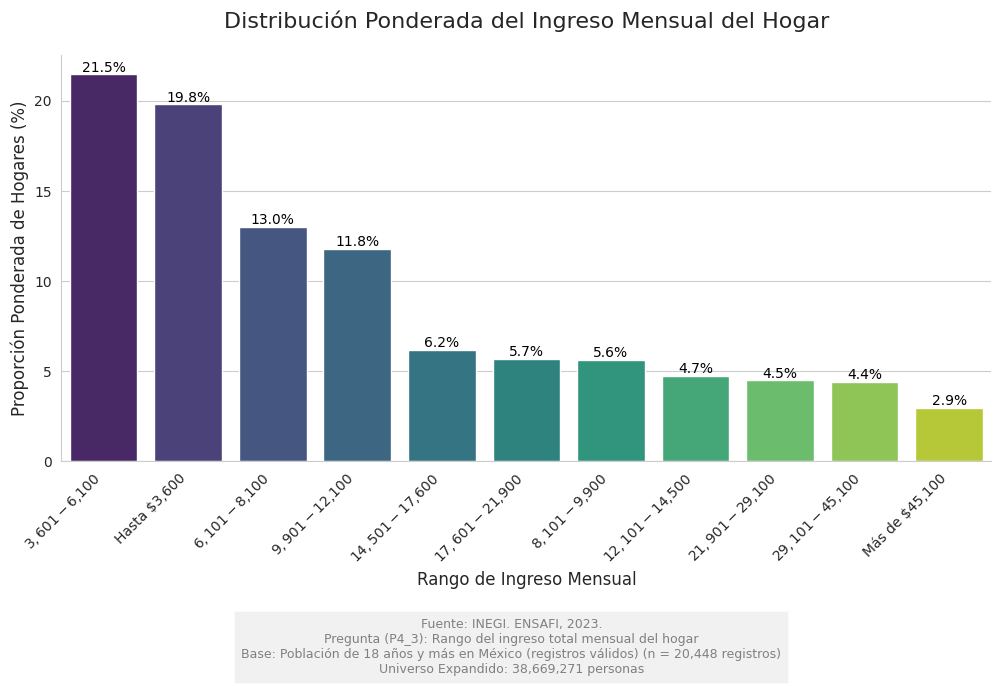

In [69]:
# Definir etiquetas de la pregunta 4_3 Rango de ingreso mensual

etiquetas_ingreso = {
    1: "Hasta $3,600",
    2: "$3,601 - $6,100",
    3: "$6,101 - $8,100",
    4: "$8,101 - $9,900",
    5: "$9,901 - $12,100",
    6: "$12,101 - $14,500",
    7: "$14,501 - $17,600",
    8: "$17,601 - $21,900",
    9: "$21,901 - $29,100",
    10: "$29,101 - $45,100",
    11: "Más de $45,100"
}

dfTH['Ingreso_Label'] = dfTH['P4_3'].map(etiquetas_ingreso)

# Filtrar valores que no se pudieron mapear (si los hubiera)
df_plot_data = dfTH.dropna(subset=['Ingreso_Label', 'FAC_HOG'])


# Calcular Frecuencias Ponderadas
# Sumamos el factor de expansión del hogar para obtener el total poblacional por categoría
frecuencias_ponderadas = df_plot_data.groupby('Ingreso_Label')['FAC_HOG'].sum()

# Calcular Proporciones
total_universo_expandido = frecuencias_ponderadas.sum()
proporciones = (frecuencias_ponderadas / total_universo_expandido) * 100

# Preparar DataFrame para la visualización
df_plot = proporciones.reset_index(name='Proporción')

# Para el pie de página, obtenemos el número de observaciones usadas
n_efectivo = len(df_plot_data)

# Visualización

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(x='Ingreso_Label',
            y='Proporción',
            hue='Ingreso_Label',
            data=df_plot.sort_values(by='Proporción', ascending=False),
            palette='viridis',
            legend=False,
            ax=ax)

# Añadir etiquetas de porcentaje en las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                 textcoords='offset points')

# Configuración del Título y Ejes
ax.set_title('Distribución Ponderada del Ingreso Mensual del Hogar', fontsize=16, pad=20)
ax.set_xlabel('Rango de Ingreso Mensual', fontsize=12)
ax.set_ylabel('Proporción Ponderada de Hogares (%)', fontsize=12)
plt.xticks(rotation=45, ha="right") # Rotar etiquetas para mejor lectura

# Eliminar el marco superior y derecho
sns.despine(top=True, right=True)

# Aplicar anotación completa
footer(ax,
       question_text="Rango del ingreso total mensual del hogar",
       mnemonic="P4_3",
       n_muestra=n_efectivo,
       universe_expansion=total_universo_expandido
      )

plt.subplots_adjust(bottom=0.30)

plt.show()

### TENENCIA DE CREDITO
* ¿Usted o alguien de su hogar tiene crédito?


____________________________________________________________________________________________________
TABLA DE RESUMEN ESTADÍSTICAS - P4.5 TENENCIA DE CRÉDITOS
____________________________________________________________________________________________________
Variable            Descripción    Sí_Pct    No_Pct  NoSabe_Pct  Total_Ponderado
  P4_5_1 Tarjeta depart./tienda 36.751883 62.850217    0.397900       32988155.0
  P4_5_2  Tarjeta/crédito banco 23.095414 76.535650    0.368935       32988155.0
  P4_5_3     Crédito automotriz  3.921392 95.801517    0.277090       32988155.0
  P4_5_4    Crédito de vivienda 15.408825 84.240498    0.350677       32988155.0
____________________________________________________________________________________________________



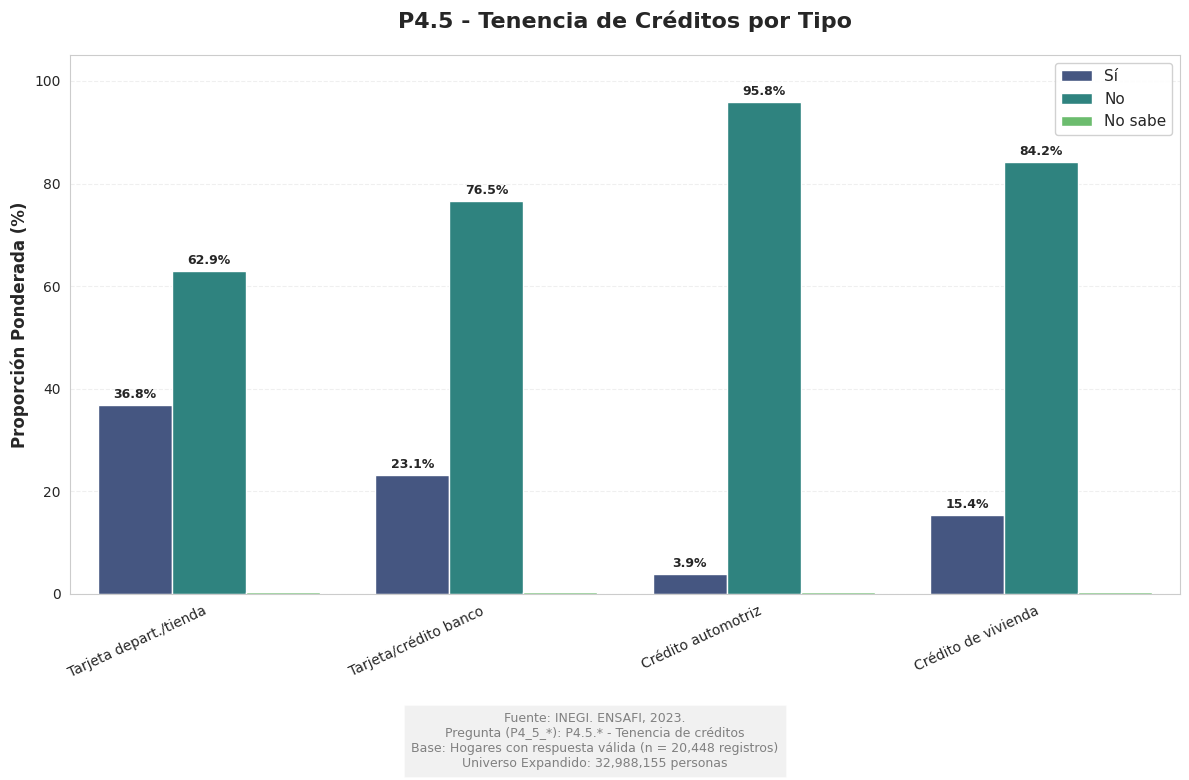

In [124]:
# CONFIGURACIÓN
WEIGHT_COL = "FAC_HOG"
P4_5_COLS = ['P4_5_1', 'P4_5_2', 'P4_5_3', 'P4_5_4']

# Etiquetas descriptivas
Etiquetas_P4_5 = {
    'P4_5_1': 'Tarjeta depart./tienda',
    'P4_5_2': 'Tarjeta/crédito banco',
    'P4_5_3': 'Crédito automotriz',
    'P4_5_4': 'Crédito de vivienda'
}

# Códigos
YES_CODE = 1
NO_CODE = 2
DK_CODE = 9 #No sabe
CATEGORIES = [YES_CODE, NO_CODE, DK_CODE]

# PREPROCESAMIENTO
# Asegurar formato numérico
dfTH[WEIGHT_COL] = pd.to_numeric(dfTH[WEIGHT_COL], errors='coerce')
for c in P4_5_COLS:
    if c in dfTH.columns:
        dfTH[c] = pd.to_numeric(dfTH[c], errors='coerce')


# FUNCIONES

def weighted_category_table(df, col, weight_col=WEIGHT_COL, categories=CATEGORIES):
    """Calcula suma de pesos por categoría."""
    mask = df[col].notna()
    grupo = df.loc[mask].groupby(col)[weight_col].sum()
    total = float(grupo.sum()) if not grupo.empty else 0.0
    rows = []
    for cat in categories:
        w = float(grupo.get(cat, 0.0))
        pct = (w / total * 100) if total > 0 else np.nan
        rows.append({'category_code': int(cat), 'weight_sum': w, 'pct': pct})
    return pd.DataFrame(rows), total


def generar_tabla_resumen_estadisticas(df_long, totals_dict):
    """Genera tabla de resumen con estadísticas descriptivas."""
    resumen = []

    for subitem in df_long['subitem'].unique():
        df_sub = df_long[df_long['subitem'] == subitem]

        # Obtener valores por categoría
        si_row = df_sub[df_sub['category_code'] == YES_CODE]
        no_row = df_sub[df_sub['category_code'] == NO_CODE]
        ns_row = df_sub[df_sub['category_code'] == DK_CODE]

        si_pct = si_row['pct'].values[0] if len(si_row) > 0 else 0
        no_pct = no_row['pct'].values[0] if len(no_row) > 0 else 0
        ns_pct = ns_row['pct'].values[0] if len(ns_row) > 0 else 0

        si_weight = si_row['weight_sum'].values[0] if len(si_row) > 0 else 0
        no_weight = no_row['weight_sum'].values[0] if len(no_row) > 0 else 0
        ns_weight = ns_row['weight_sum'].values[0] if len(ns_row) > 0 else 0

        total_weight = totals_dict.get(subitem, 0)

        resumen.append({
            'Variable': subitem,
            'Descripción': df_sub['subitem_label'].iloc[0],
            'Sí_Pct': si_pct,
            'No_Pct': no_pct,
            'NoSabe_Pct': ns_pct,
            'Sí_Ponderado': si_weight,
            'No_Ponderado': no_weight,
            'NoSabe_Ponderado': ns_weight,
            'Total_Ponderado': total_weight
        })

    return pd.DataFrame(resumen)

def footer(ax, question, mnemonic, base_desc, n_muestra, universe_expansion):
    """Añade pie de página al gráfico."""
    footer_text = (
        f"Fuente: INEGI. ENSAFI, 2023.\n"
        f"Pregunta ({mnemonic}): {question}\n"
        f"Base: {base_desc} (n = {n_muestra:,.0f} registros)\n"
        f"Universo Expandido: {universe_expansion:,.0f} personas"
    )
    plt.figtext(0.5, -0.1,
                footer_text,
                wrap=True,
                horizontalalignment='center',
                fontsize=9,
                color='gray',
                bbox={"facecolor": "lightgray", "alpha": 0.3, "pad": 5})


# PROCESAMIENTO DE DATOS

# Construir tabla larga
rows_long = []
totals = {}

for c in P4_5_COLS:
    if c not in dfTH.columns:
        continue
    tab, tot = weighted_category_table(dfTH, c)
    totals[c] = tot
    for _, r in tab.iterrows():
        cat_label = ('Sí' if r['category_code'] == YES_CODE
                    else ('No' if r['category_code'] == NO_CODE else 'No sabe'))
        rows_long.append({
            'subitem': c,
            'subitem_label': Etiquetas_P4_5.get(c, c),
            'category_code': int(r['category_code']),
            'category_label': cat_label,
            'weight_sum': r['weight_sum'],
            'pct': r['pct']
        })

df_p4_5_long = pd.DataFrame(rows_long)

# Generar tabla de resumen
df_resumen_estadisticas = generar_tabla_resumen_estadisticas(df_p4_5_long, totals)

# Crear pivot (ancho) para revisión rápida
df_p4_5_wide = df_p4_5_long.pivot_table(
    index='subitem_label',
    columns='category_label',
    values='pct',
    aggfunc='first'
)


# MOSTRAR TABLA DE RESUMEN


print("\n" + "_" * 100)
print("TABLA DE RESUMEN ESTADÍSTICAS - P4.5 TENENCIA DE CRÉDITOS")
print("_" * 100)
print(df_resumen_estadisticas[['Variable', 'Descripción', 'Sí_Pct', 'No_Pct',
                                'NoSabe_Pct', 'Total_Ponderado']].to_string(index=False))
print("_" * 100 + "\n")


# VISUALIZACIÓN
# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=df_p4_5_long,
    x='subitem_label',
    y='pct',
    hue='category_label',
    palette='viridis',
    ax=ax
)

ax.set_title('P4.5 - Tenencia de Créditos por Tipo',
             fontsize=16, weight='bold', pad=20)
ax.set_ylabel('Proporción Ponderada (%)', fontsize=12, weight='bold')
ax.set_xlabel('', fontsize=12)
ax.set_ylim(0, 105)
plt.xticks(rotation=25, ha='right', fontsize=10)

# Anotar barras con porcentajes
for p in ax.patches:
    h = p.get_height()
    if not np.isnan(h) and h > 2:  # Solo mostrar si > 2%
        ax.annotate(
            f"{h:.1f}%",
            (p.get_x() + p.get_width() / 2., h),
            ha='center',
            va='bottom',
            fontsize=9,
            weight='bold',
            xytext=(0, 3),
            textcoords='offset points'
        )

# Grid
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Leyenda
ax.legend(title='', fontsize=11, loc='upper right', framealpha=0.9)

footer(ax,
       question="P4.5.* - Tenencia de créditos",
       mnemonic="P4_5_*",
       base_desc="Hogares con respuesta válida",
       n_muestra=len(dfTH),
       universe_expansion=sum(totals.values())/4
      )

plt.subplots_adjust(bottom=0.20)
plt.tight_layout()
plt.show()

### HÁBITOS DE AHORRO
* ¿Usted o alguien de su hogar acostumbra ahorrar?


____________________________________________________________________________________________________
TABLA DE RESUMEN ESTADÍSTICAS - P4.6 HÁBITOS DE AHORRO
____________________________________________________________________________________________________
Variable                           Descripción    Sí_Pct    No_Pct  NoSabe_Pct  Total_Ponderado
  P4_6_1                       Cuenta de banco 19.350191 80.202351    0.447458       32988155.0
  P4_6_2 Cuenta de ahorro para el retiro/AFORE 15.061394 84.150432    0.788174       32988155.0
  P4_6_3                 Tandas/Caja de ahorro 14.647746 84.997991    0.354264       32988155.0
  P4_6_4                Familiares o amistades  5.524786 94.143749    0.331464       32988155.0
  P4_6_5                     Dinero en su casa 30.640713 68.961389    0.397897       32988155.0
____________________________________________________________________________________________________



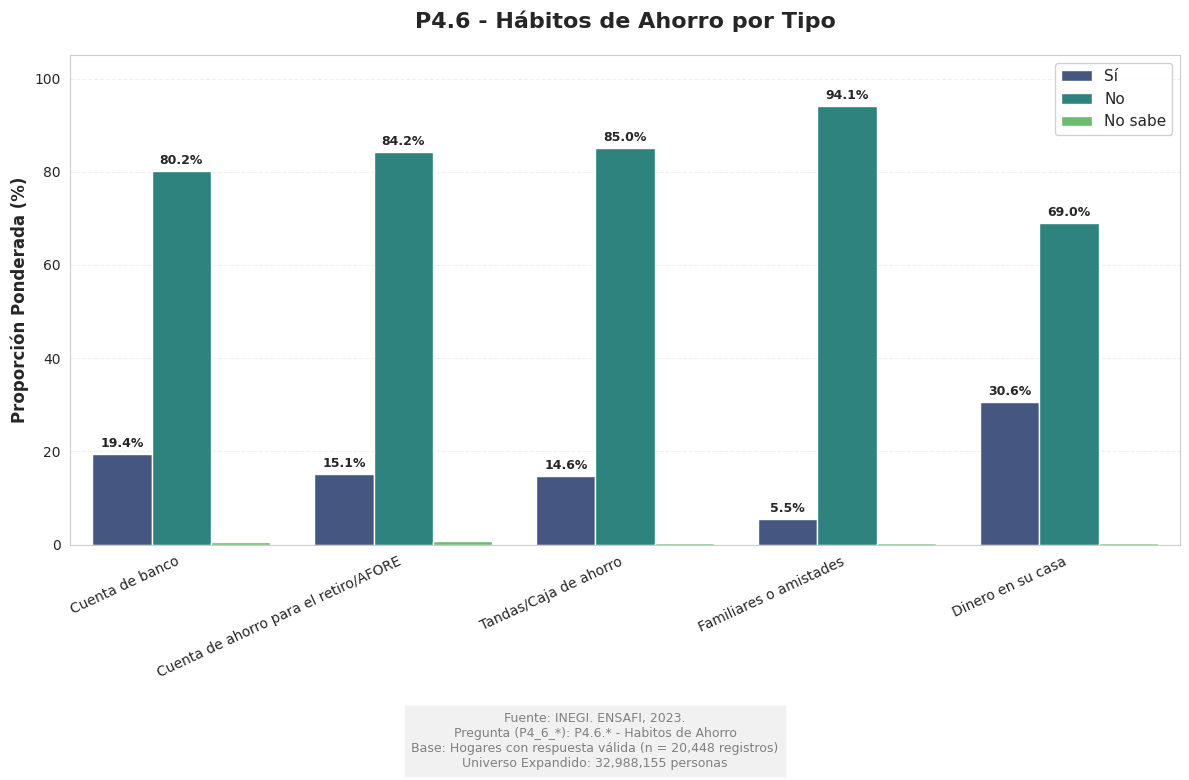

In [125]:
# CONFIGURACIÓN
WEIGHT_COL = "FAC_HOG"
P4_6_COLS = ['P4_6_1', 'P4_6_2', 'P4_6_3', 'P4_6_4', 'P4_6_5']

# Etiquetas descriptivas
Etiquetas_P4_6 = {
    'P4_6_1': 'Cuenta de banco',
    'P4_6_2': 'Cuenta de ahorro para el retiro/AFORE',
    'P4_6_3': 'Tandas/Caja de ahorro',
    'P4_6_4': 'Familiares o amistades',
    'P4_6_5': 'Dinero en su casa'
}

# Códigos
YES_CODE = 1
NO_CODE = 2
DK_CODE = 9 #No sabe
CATEGORIES = [YES_CODE, NO_CODE, DK_CODE]

# PREPROCESAMIENTO
# Asegurar formato numérico
dfTH[WEIGHT_COL] = pd.to_numeric(dfTH[WEIGHT_COL], errors='coerce')
for c in P4_6_COLS:
    if c in dfTH.columns:
        dfTH[c] = pd.to_numeric(dfTH[c], errors='coerce')


# FUNCIONES

def weighted_category_table(df, col, weight_col=WEIGHT_COL, categories=CATEGORIES):
    """Calcula suma de pesos por categoría."""
    mask = df[col].notna()
    grupo = df.loc[mask].groupby(col)[weight_col].sum()
    total = float(grupo.sum()) if not grupo.empty else 0.0
    rows = []
    for cat in categories:
        w = float(grupo.get(cat, 0.0))
        pct = (w / total * 100) if total > 0 else np.nan
        rows.append({'category_code': int(cat), 'weight_sum': w, 'pct': pct})
    return pd.DataFrame(rows), total


def generar_tabla_resumen_estadisticas(df_long, totals_dict):
    """Genera tabla de resumen con estadísticas descriptivas."""
    resumen = []

    for subitem in df_long['subitem'].unique():
        df_sub = df_long[df_long['subitem'] == subitem]

        # Obtener valores por categoría
        si_row = df_sub[df_sub['category_code'] == YES_CODE]
        no_row = df_sub[df_sub['category_code'] == NO_CODE]
        ns_row = df_sub[df_sub['category_code'] == DK_CODE]

        si_pct = si_row['pct'].values[0] if len(si_row) > 0 else 0
        no_pct = no_row['pct'].values[0] if len(no_row) > 0 else 0
        ns_pct = ns_row['pct'].values[0] if len(ns_row) > 0 else 0

        si_weight = si_row['weight_sum'].values[0] if len(si_row) > 0 else 0
        no_weight = no_row['weight_sum'].values[0] if len(no_row) > 0 else 0
        ns_weight = ns_row['weight_sum'].values[0] if len(ns_row) > 0 else 0

        total_weight = totals_dict.get(subitem, 0)

        resumen.append({
            'Variable': subitem,
            'Descripción': df_sub['subitem_label'].iloc[0],
            'Sí_Pct': si_pct,
            'No_Pct': no_pct,
            'NoSabe_Pct': ns_pct,
            'Sí_Ponderado': si_weight,
            'No_Ponderado': no_weight,
            'NoSabe_Ponderado': ns_weight,
            'Total_Ponderado': total_weight
        })

    return pd.DataFrame(resumen)

def footer(ax, question, mnemonic, base_desc, n_muestra, universe_expansion):
    """Añade pie de página al gráfico."""
    footer_text = (
        f"Fuente: INEGI. ENSAFI, 2023.\n"
        f"Pregunta ({mnemonic}): {question}\n"
        f"Base: {base_desc} (n = {n_muestra:,.0f} registros)\n"
        f"Universo Expandido: {universe_expansion:,.0f} personas"
    )
    plt.figtext(0.5, -0.1,
                footer_text,
                wrap=True,
                horizontalalignment='center',
                fontsize=9,
                color='gray',
                bbox={"facecolor": "lightgray", "alpha": 0.3, "pad": 5})


# PROCESAMIENTO DE DATOS

# Construir tabla larga
rows_long = []
totals = {}

for c in P4_6_COLS:
    if c not in dfTH.columns:
        continue
    tab, tot = weighted_category_table(dfTH, c)
    totals[c] = tot
    for _, r in tab.iterrows():
        cat_label = ('Sí' if r['category_code'] == YES_CODE
                    else ('No' if r['category_code'] == NO_CODE else 'No sabe'))
        rows_long.append({
            'subitem': c,
            'subitem_label': Etiquetas_P4_6.get(c, c),
            'category_code': int(r['category_code']),
            'category_label': cat_label,
            'weight_sum': r['weight_sum'],
            'pct': r['pct']
        })

df_p4_6_long = pd.DataFrame(rows_long)

# Generar tabla de resumen
df_resumen_estadisticas = generar_tabla_resumen_estadisticas(df_p4_6_long, totals)

# Crear pivot (ancho) para revisión rápida
df_p4_6_wide = df_p4_6_long.pivot_table(
    index='subitem_label',
    columns='category_label',
    values='pct',
    aggfunc='first'
)


# MOSTRAR TABLA DE RESUMEN


print("\n" + "_" * 100)
print("TABLA DE RESUMEN ESTADÍSTICAS - P4.6 HÁBITOS DE AHORRO")
print("_" * 100)
print(df_resumen_estadisticas[['Variable', 'Descripción', 'Sí_Pct', 'No_Pct',
                                'NoSabe_Pct', 'Total_Ponderado']].to_string(index=False))
print("_" * 100 + "\n")


# VISUALIZACIÓN
# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=df_p4_6_long,
    x='subitem_label',
    y='pct',
    hue='category_label',
    palette='viridis',
    ax=ax
)

ax.set_title('P4.6 - Hábitos de Ahorro por Tipo',
             fontsize=16, weight='bold', pad=20)
ax.set_ylabel('Proporción Ponderada (%)', fontsize=12, weight='bold')
ax.set_xlabel('', fontsize=12)
ax.set_ylim(0, 105)
plt.xticks(rotation=25, ha='right', fontsize=10)

# Anotar barras con porcentajes
for p in ax.patches:
    h = p.get_height()
    if not np.isnan(h) and h > 2:  # Solo mostrar si > 2%
        ax.annotate(
            f"{h:.1f}%",
            (p.get_x() + p.get_width() / 2., h),
            ha='center',
            va='bottom',
            fontsize=9,
            weight='bold',
            xytext=(0, 3),
            textcoords='offset points'
        )

# Grid
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Leyenda
ax.legend(title='', fontsize=11, loc='upper right', framealpha=0.9)

footer(ax,
       question="P4.6.* - Habitos de Ahorro",
       mnemonic="P4_6_*",
       base_desc="Hogares con respuesta válida",
       n_muestra=len(dfTH),
       universe_expansion=sum(totals.values())/5
      )

plt.subplots_adjust(bottom=0.20)
plt.tight_layout()
plt.show()

### CONDICIÓN DE DEUDA
* ¿Usted o alguien de su hogar tiene deuda?


____________________________________________________________________________________________________
TABLA DE RESUMEN ESTADÍSTICAS - P4.7 CONDICIÓN DE DEUDA
____________________________________________________________________________________________________
Variable                                Descripción    Sí_Pct    No_Pct  NoSabe_Pct  Total_Ponderado
  P4_7_1                 Tarjeta o crédito de banco 27.029347 72.615140    0.355512       32988155.0
  P4_7_2 Caja de ahorro, con familiares o amistades  4.910363 94.831636    0.258002       32988155.0
  P4_7_3                             Casa de empeño  1.944304 97.842453    0.213243       32988155.0
  P4_7_4                  Prestamistas o agiotistas  1.855072 98.054086    0.090842       32988155.0
____________________________________________________________________________________________________



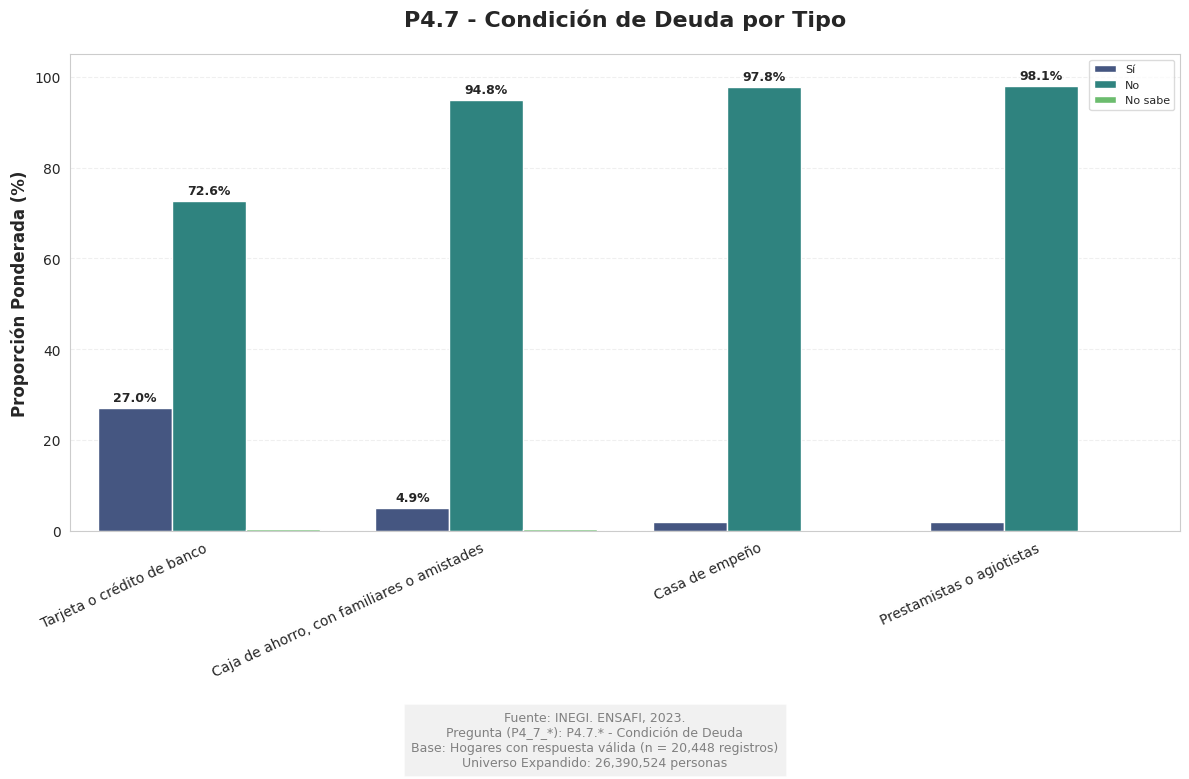

In [131]:
# CONFIGURACIÓN
WEIGHT_COL = "FAC_HOG"
P4_7_COLS = ['P4_7_1', 'P4_7_2', 'P4_7_3', 'P4_7_4']

# Etiquetas descriptivas
Etiquetas_P4_7 = {
    'P4_7_1': 'Tarjeta o crédito de banco',
    'P4_7_2': 'Caja de ahorro, con familiares o amistades',
    'P4_7_3': 'Casa de empeño',
    'P4_7_4': 'Prestamistas o agiotistas'
}

# Códigos
YES_CODE = 1
NO_CODE = 2
DK_CODE = 9 #No sabe
CATEGORIES = [YES_CODE, NO_CODE, DK_CODE]

# PREPROCESAMIENTO
# Asegurar formato numérico
dfTH[WEIGHT_COL] = pd.to_numeric(dfTH[WEIGHT_COL], errors='coerce')
for c in P4_7_COLS:
    if c in dfTH.columns:
        dfTH[c] = pd.to_numeric(dfTH[c], errors='coerce')


# FUNCIONES

def weighted_category_table(df, col, weight_col=WEIGHT_COL, categories=CATEGORIES):
    """Calcula suma de pesos por categoría."""
    mask = df[col].notna()
    grupo = df.loc[mask].groupby(col)[weight_col].sum()
    total = float(grupo.sum()) if not grupo.empty else 0.0
    rows = []
    for cat in categories:
        w = float(grupo.get(cat, 0.0))
        pct = (w / total * 100) if total > 0 else np.nan
        rows.append({'category_code': int(cat), 'weight_sum': w, 'pct': pct})
    return pd.DataFrame(rows), total


def generar_tabla_resumen_estadisticas(df_long, totals_dict):
    """Genera tabla de resumen con estadísticas descriptivas."""
    resumen = []

    for subitem in df_long['subitem'].unique():
        df_sub = df_long[df_long['subitem'] == subitem]

        # Obtener valores por categoría
        si_row = df_sub[df_sub['category_code'] == YES_CODE]
        no_row = df_sub[df_sub['category_code'] == NO_CODE]
        ns_row = df_sub[df_sub['category_code'] == DK_CODE]

        si_pct = si_row['pct'].values[0] if len(si_row) > 0 else 0
        no_pct = no_row['pct'].values[0] if len(no_row) > 0 else 0
        ns_pct = ns_row['pct'].values[0] if len(ns_row) > 0 else 0

        si_weight = si_row['weight_sum'].values[0] if len(si_row) > 0 else 0
        no_weight = no_row['weight_sum'].values[0] if len(no_row) > 0 else 0
        ns_weight = ns_row['weight_sum'].values[0] if len(ns_row) > 0 else 0

        total_weight = totals_dict.get(subitem, 0)

        resumen.append({
            'Variable': subitem,
            'Descripción': df_sub['subitem_label'].iloc[0],
            'Sí_Pct': si_pct,
            'No_Pct': no_pct,
            'NoSabe_Pct': ns_pct,
            'Sí_Ponderado': si_weight,
            'No_Ponderado': no_weight,
            'NoSabe_Ponderado': ns_weight,
            'Total_Ponderado': total_weight
        })

    return pd.DataFrame(resumen)

def footer(ax, question, mnemonic, base_desc, n_muestra, universe_expansion):
    """Añade pie de página al gráfico."""
    footer_text = (
        f"Fuente: INEGI. ENSAFI, 2023.\n"
        f"Pregunta ({mnemonic}): {question}\n"
        f"Base: {base_desc} (n = {n_muestra:,.0f} registros)\n"
        f"Universo Expandido: {universe_expansion:,.0f} personas"
    )
    plt.figtext(0.5, -0.1,
                footer_text,
                wrap=True,
                horizontalalignment='center',
                fontsize=9,
                color='gray',
                bbox={"facecolor": "lightgray", "alpha": 0.3, "pad": 5})


# PROCESAMIENTO DE DATOS

# Construir tabla larga
rows_long = []
totals = {}

for c in P4_7_COLS:
    if c not in dfTH.columns:
        continue
    tab, tot = weighted_category_table(dfTH, c)
    totals[c] = tot
    for _, r in tab.iterrows():
        cat_label = ('Sí' if r['category_code'] == YES_CODE
                    else ('No' if r['category_code'] == NO_CODE else 'No sabe'))
        rows_long.append({
            'subitem': c,
            'subitem_label': Etiquetas_P4_7.get(c, c),
            'category_code': int(r['category_code']),
            'category_label': cat_label,
            'weight_sum': r['weight_sum'],
            'pct': r['pct']
        })

df_p4_7_long = pd.DataFrame(rows_long)

# Generar tabla de resumen
df_resumen_estadisticas = generar_tabla_resumen_estadisticas(df_p4_7_long, totals)

# Crear pivot (ancho) para revisión rápida
df_p4_7_wide = df_p4_7_long.pivot_table(
    index='subitem_label',
    columns='category_label',
    values='pct',
    aggfunc='first'
)


# MOSTRAR TABLA DE RESUMEN


print("\n" + "_" * 100)
print("TABLA DE RESUMEN ESTADÍSTICAS - P4.7 CONDICIÓN DE DEUDA")
print("_" * 100)
print(df_resumen_estadisticas[['Variable', 'Descripción', 'Sí_Pct', 'No_Pct',
                                'NoSabe_Pct', 'Total_Ponderado']].to_string(index=False))
print("_" * 100 + "\n")


# VISUALIZACIÓN
# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=df_p4_7_long,
    x='subitem_label',
    y='pct',
    hue='category_label',
    palette='viridis',
    ax=ax
)

ax.set_title('P4.7 - Condición de Deuda por Tipo',
             fontsize=16, weight='bold', pad=20)
ax.set_ylabel('Proporción Ponderada (%)', fontsize=12, weight='bold')
ax.set_xlabel('', fontsize=12)
ax.set_ylim(0, 105)
plt.xticks(rotation=25, ha='right', fontsize=10)

# Anotar barras con porcentajes
for p in ax.patches:
    h = p.get_height()
    if not np.isnan(h) and h > 2:  # Solo mostrar si > 2%
        ax.annotate(
            f"{h:.1f}%",
            (p.get_x() + p.get_width() / 2., h),
            ha='center',
            va='bottom',
            fontsize=9,
            weight='bold',
            xytext=(0, 3),
            textcoords='offset points'
        )

# Grid
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Leyenda
ax.legend(title='', fontsize=8, loc='upper right', framealpha=0.7)

footer(ax,
       question="P4.7.* - Condición de Deuda",
       mnemonic="P4_7_*",
       base_desc="Hogares con respuesta válida",
       n_muestra=len(dfTH),
       universe_expansion=sum(totals.values())/5
      )

plt.subplots_adjust(bottom=0.20)
plt.tight_layout()
plt.show()

### PRIVACIÓN ECONÓMICA
* En los últimos tres meses, ¿en su hogar tuvieron dinero suficiente para...


____________________________________________________________________________________________________
TABLA DE RESUMEN ESTADÍSTICAS - P4.10 PRIVACIÓN ECONÓMICA
____________________________________________________________________________________________________
Variable                                        Descripción    Sí_Pct    No_Pct  NoSabe_Pct  Total_Ponderado
 P4_10_1                                   La comida diaria 84.457612 15.491409    0.050978       38669271.0
 P4_10_2 Mantenimiento a la casa o pagar la renta o crédito 59.362076 40.563175    0.074749       38669271.0
 P4_10_3                             Comprar ropa y calzado 60.149505 39.774962    0.075533       38669271.0
 P4_10_4                         Pagar gastos de transporte 79.222148 20.713253    0.064599       38669271.0
 P4_10_5                  Pagar medicinas o atención médica 73.777995 26.128266    0.093739       38669271.0
 P4_10_6                        Entretenimiento o diversión 41.083779 58.711565    0.

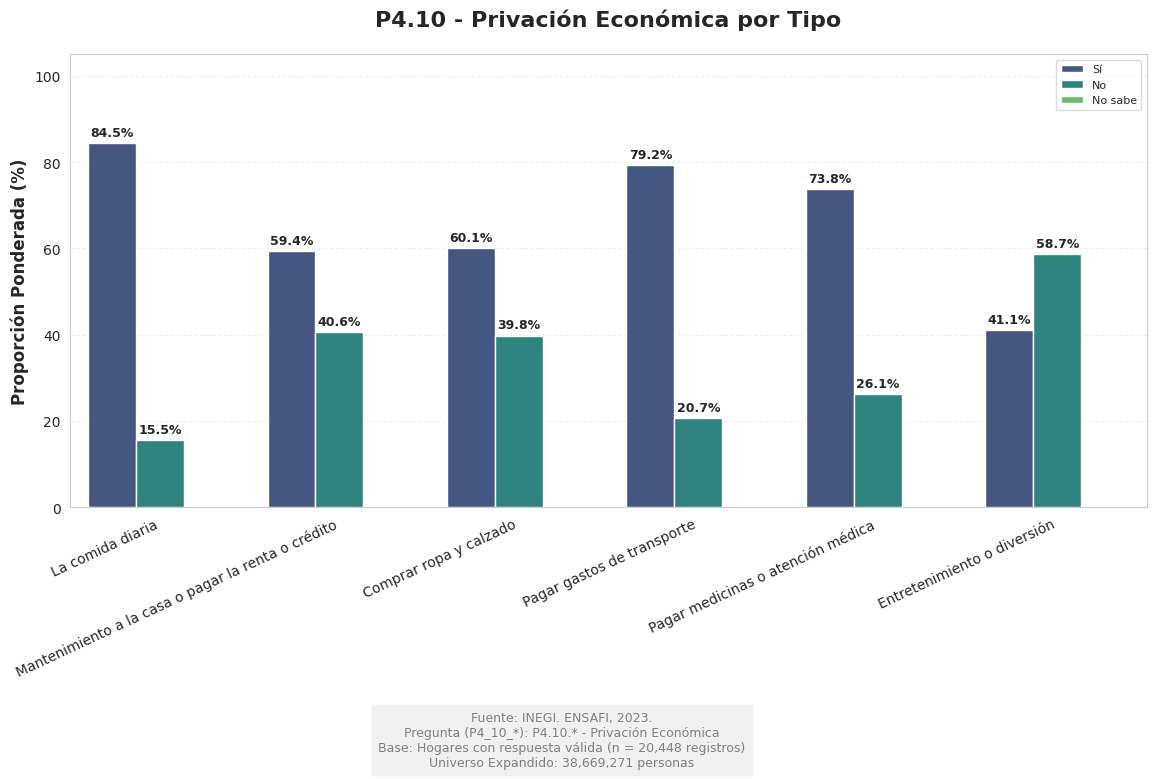

In [133]:
# CONFIGURACIÓN
WEIGHT_COL = "FAC_HOG"
P4_10_COLS = ['P4_10_1', 'P4_10_2', 'P4_10_3', 'P4_10_4', 'P4_10_5', 'P4_10_6']

# Etiquetas descriptivas
Etiquetas_P4_10 = {
    'P4_10_1': 'La comida diaria',
    'P4_10_2': 'Mantenimiento a la casa o pagar la renta o crédito',
    'P4_10_3': 'Comprar ropa y calzado',
    'P4_10_4': 'Pagar gastos de transporte',
    'P4_10_5': 'Pagar medicinas o atención médica',
    'P4_10_6': 'Entretenimiento o diversión'
}

# Códigos
YES_CODE = 1
NO_CODE = 2
DK_CODE = 9 #No sabe
CATEGORIES = [YES_CODE, NO_CODE, DK_CODE]

# PREPROCESAMIENTO
# Asegurar formato numérico
dfTH[WEIGHT_COL] = pd.to_numeric(dfTH[WEIGHT_COL], errors='coerce')
for c in P4_10_COLS:
    if c in dfTH.columns:
        dfTH[c] = pd.to_numeric(dfTH[c], errors='coerce')


# FUNCIONES

def weighted_category_table(df, col, weight_col=WEIGHT_COL, categories=CATEGORIES):
    """Calcula suma de pesos por categoría."""
    mask = df[col].notna()
    grupo = df.loc[mask].groupby(col)[weight_col].sum()
    total = float(grupo.sum()) if not grupo.empty else 0.0
    rows = []
    for cat in categories:
        w = float(grupo.get(cat, 0.0))
        pct = (w / total * 100) if total > 0 else np.nan
        rows.append({'category_code': int(cat), 'weight_sum': w, 'pct': pct})
    return pd.DataFrame(rows), total


def generar_tabla_resumen_estadisticas(df_long, totals_dict):
    """Genera tabla de resumen con estadísticas descriptivas."""
    resumen = []

    for subitem in df_long['subitem'].unique():
        df_sub = df_long[df_long['subitem'] == subitem]

        # Obtener valores por categoría
        si_row = df_sub[df_sub['category_code'] == YES_CODE]
        no_row = df_sub[df_sub['category_code'] == NO_CODE]
        ns_row = df_sub[df_sub['category_code'] == DK_CODE]

        si_pct = si_row['pct'].values[0] if len(si_row) > 0 else 0
        no_pct = no_row['pct'].values[0] if len(no_row) > 0 else 0
        ns_pct = ns_row['pct'].values[0] if len(ns_row) > 0 else 0

        si_weight = si_row['weight_sum'].values[0] if len(si_row) > 0 else 0
        no_weight = no_row['weight_sum'].values[0] if len(no_row) > 0 else 0
        ns_weight = ns_row['weight_sum'].values[0] if len(ns_row) > 0 else 0

        total_weight = totals_dict.get(subitem, 0)

        resumen.append({
            'Variable': subitem,
            'Descripción': df_sub['subitem_label'].iloc[0],
            'Sí_Pct': si_pct,
            'No_Pct': no_pct,
            'NoSabe_Pct': ns_pct,
            'Sí_Ponderado': si_weight,
            'No_Ponderado': no_weight,
            'NoSabe_Ponderado': ns_weight,
            'Total_Ponderado': total_weight
        })

    return pd.DataFrame(resumen)

def footer(ax, question, mnemonic, base_desc, n_muestra, universe_expansion):
    """Añade pie de página al gráfico."""
    footer_text = (
        f"Fuente: INEGI. ENSAFI, 2023.\n"
        f"Pregunta ({mnemonic}): {question}\n"
        f"Base: {base_desc} (n = {n_muestra:,.0f} registros)\n"
        f"Universo Expandido: {universe_expansion:,.0f} personas"
    )
    plt.figtext(0.5, -0.1,
                footer_text,
                wrap=True,
                horizontalalignment='center',
                fontsize=9,
                color='gray',
                bbox={"facecolor": "lightgray", "alpha": 0.3, "pad": 5})


# PROCESAMIENTO DE DATOS

# Construir tabla larga
rows_long = []
totals = {}

for c in P4_10_COLS:
    if c not in dfTH.columns:
        continue
    tab, tot = weighted_category_table(dfTH, c)
    totals[c] = tot
    for _, r in tab.iterrows():
        cat_label = ('Sí' if r['category_code'] == YES_CODE
                    else ('No' if r['category_code'] == NO_CODE else 'No sabe'))
        rows_long.append({
            'subitem': c,
            'subitem_label': Etiquetas_P4_10.get(c, c),
            'category_code': int(r['category_code']),
            'category_label': cat_label,
            'weight_sum': r['weight_sum'],
            'pct': r['pct']
        })

df_p4_10_long = pd.DataFrame(rows_long)

# Generar tabla de resumen
df_resumen_estadisticas = generar_tabla_resumen_estadisticas(df_p4_10_long, totals)

# Crear pivot (ancho) para revisión rápida
df_p4_10_wide = df_p4_10_long.pivot_table(
    index='subitem_label',
    columns='category_label',
    values='pct',
    aggfunc='first'
)


# MOSTRAR TABLA DE RESUMEN


print("\n" + "_" * 100)
print("TABLA DE RESUMEN ESTADÍSTICAS - P4.10 PRIVACIÓN ECONÓMICA")
print("_" * 100)
print(df_resumen_estadisticas[['Variable', 'Descripción', 'Sí_Pct', 'No_Pct',
                                'NoSabe_Pct', 'Total_Ponderado']].to_string(index=False))
print("_" * 100 + "\n")


# VISUALIZACIÓN
# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=df_p4_10_long,
    x='subitem_label',
    y='pct',
    hue='category_label',
    palette='viridis',
    ax=ax
)

ax.set_title('P4.10 - Privación Económica por Tipo',
             fontsize=16, weight='bold', pad=20)
ax.set_ylabel('Proporción Ponderada (%)', fontsize=12, weight='bold')
ax.set_xlabel('', fontsize=12)
ax.set_ylim(0, 105)
plt.xticks(rotation=25, ha='right', fontsize=10)

# Anotar barras con porcentajes
for p in ax.patches:
    h = p.get_height()
    if not np.isnan(h) and h > 2:  # Solo mostrar si > 2%
        ax.annotate(
            f"{h:.1f}%",
            (p.get_x() + p.get_width() / 2., h),
            ha='center',
            va='bottom',
            fontsize=9,
            weight='bold',
            xytext=(0, 3),
            textcoords='offset points'
        )

# Grid
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Leyenda
ax.legend(title='', fontsize=8, loc='upper right', framealpha=0.7)

footer(ax,
       question="P4.10.* - Privación Económica",
       mnemonic="P4_10_*",
       base_desc="Hogares con respuesta válida",
       n_muestra=len(dfTH),
       universe_expansion=sum(totals.values())/6
      )

plt.subplots_adjust(bottom=0.20)
plt.tight_layout()
plt.show()

# ANÁLISIS EXPLORATORIO DE LOS DATOS (EDA)

En datos categoricos no es conveniente realizar análisis con `describe()`, por lo cual solo se acotó a la variable P4_2

In [150]:
# Estadísticas descriptivas
print('El EDA de la columna P4_2 (Ingreso total mensual del hogar) es: ') #sin considerar el factor de expansión
print(dfTH[['P4_2']].describe())
print('\n')




El EDA de la columna P4_2 (Ingreso total mensual del hogar) es: 
               P4_2
count  20448.000000
mean   18300.922046
std    26119.253755
min      200.000000
25%     5000.000000
50%     8400.000000
75%    16300.000000
max    99999.000000




## Verificación de valores faltantes
* Observamos que los valores faltantes corresponden al diseño de la encuesta, la cual en algunas preguntas no aplican, derivado de una respuesta negativa en una pregunta anterior

In [152]:
# Verificar valores faltantes y tipos de datos
print("Valores faltantes por diseño:")
print(dfTH.isnull().sum())
print(dfTH.info())

Valores faltantes por diseño:
LLAVEHOG             0
LLAVEVIV             0
P4_1_1               0
P4_1_2               0
P4_1_3               0
P4_1_4               0
P4_1_5               0
P4_1_6               0
P4_1_7               0
P4_1_8               0
P4_1_9               0
P4_2                 0
P4_3                 0
FILTRO_S4_1          0
P4_4_1            3107
P4_4_2            3107
P4_5_1            3107
P4_5_2            3107
P4_5_3            3107
P4_5_4            3107
P4_6_1            3107
P4_6_2            3107
P4_6_3            3107
P4_6_4            3107
P4_6_5            3107
P4_7_1            3107
P4_8_1           15551
P4_7_2            3107
P4_8_2           19526
P4_7_3            3107
P4_8_3           20049
P4_7_4            3107
P4_8_4           20094
P4_9_1            3107
P4_9_2            3107
P4_9_3            3107
P4_9_4            3107
P4_9_5            3107
P4_9_6            3107
P4_10_1              0
P4_10_2              0
P4_10_3              0
P4_1

## Realizamos una inspección rápida de nuestro dataframe, la mayoría de las columnas corresponden a datos categoricos

In [160]:
print(dfTH.shape)
print(dfTH.columns[:50] )  # inspección rápida
print(dfTH.head())

(20448, 56)
Index(['LLAVEHOG', 'LLAVEVIV', 'P4_1_1', 'P4_1_2', 'P4_1_3', 'P4_1_4',
       'P4_1_5', 'P4_1_6', 'P4_1_7', 'P4_1_8', 'P4_1_9', 'P4_2', 'P4_3',
       'FILTRO_S4_1', 'P4_4_1', 'P4_4_2', 'P4_5_1', 'P4_5_2', 'P4_5_3',
       'P4_5_4', 'P4_6_1', 'P4_6_2', 'P4_6_3', 'P4_6_4', 'P4_6_5', 'P4_7_1',
       'P4_8_1', 'P4_7_2', 'P4_8_2', 'P4_7_3', 'P4_8_3', 'P4_7_4', 'P4_8_4',
       'P4_9_1', 'P4_9_2', 'P4_9_3', 'P4_9_4', 'P4_9_5', 'P4_9_6', 'P4_10_1',
       'P4_10_2', 'P4_10_3', 'P4_10_4', 'P4_10_5', 'P4_10_6', 'UPM', 'VIV_SEL',
       'HOGAR', 'ENT', 'MUN'],
      dtype='object')
    LLAVEHOG  LLAVEVIV  P4_1_1  P4_1_2  P4_1_3  P4_1_4  P4_1_5  P4_1_6  \
0  505941161  50594116       1       1       2       2       2       2   
1  505941171  50594117       2       1       2       2       2       2   
2  505941181  50594118       2       2       2       2       2       2   
3  505941191  50594119       1       1       2       2       2       2   
4  505941201  50594120       2       

Variables a graficar: ['log_P4_2', 'n_creditos', 'n_ahorro', 'n_deudas', 'n_privacion']


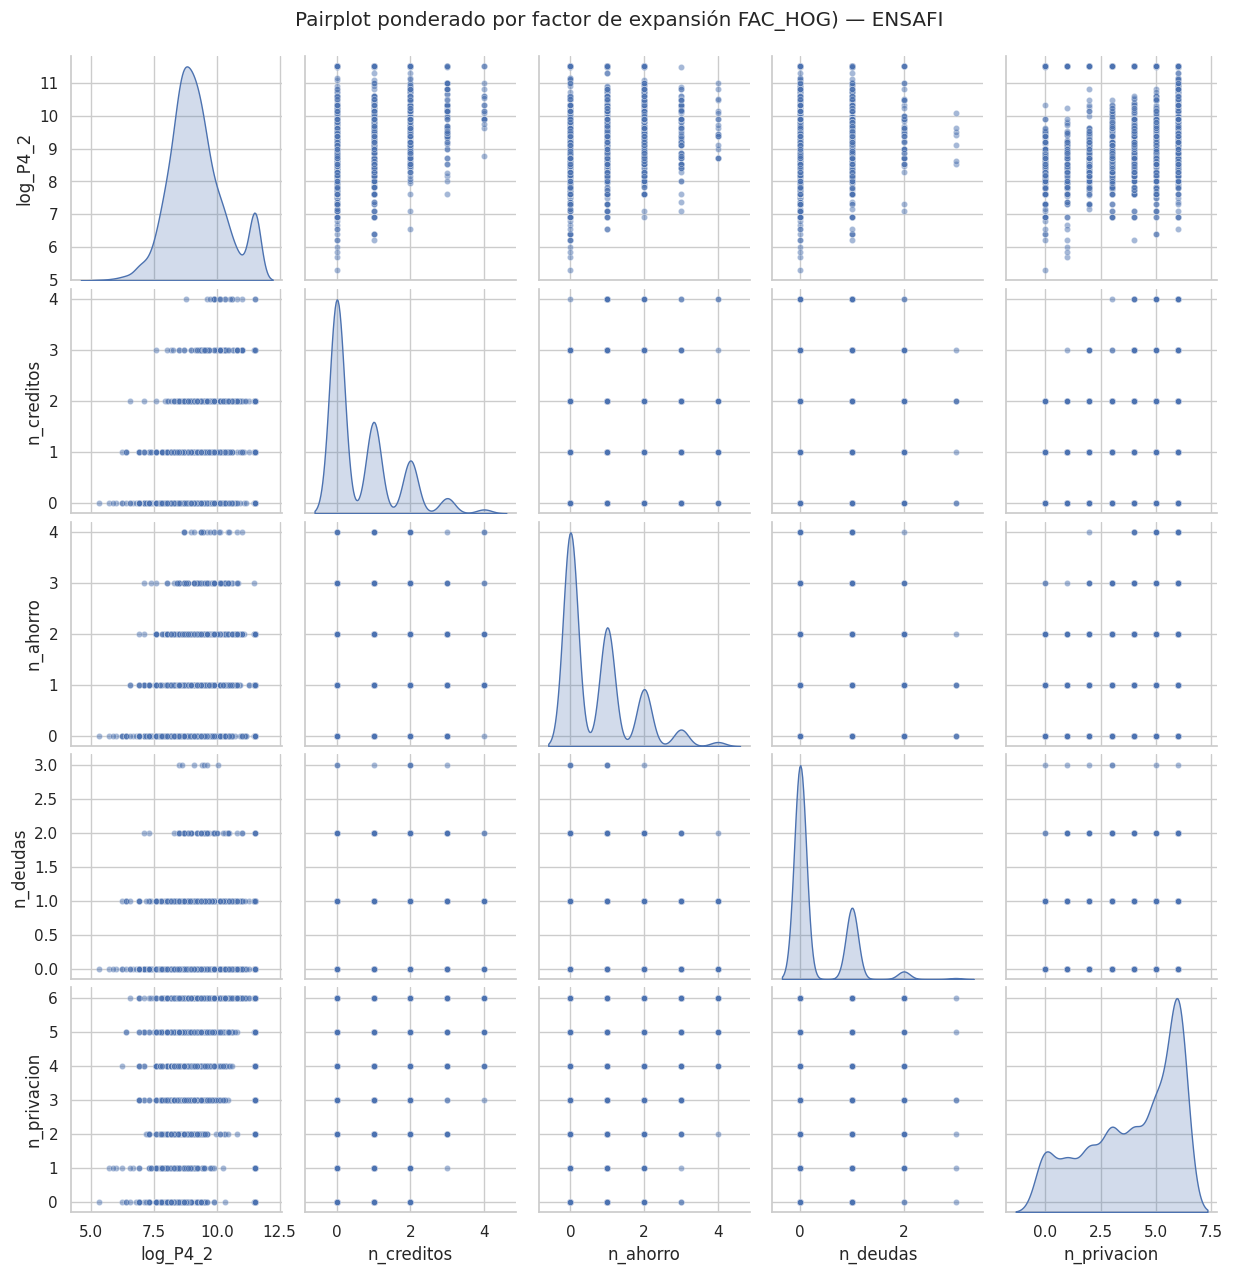


Matriz de correlación ponderada (FAC_HOG):
              log_P4_2  n_creditos  n_ahorro  n_deudas  n_privacion
log_P4_2     1.000000    0.317075  0.182017  0.138352     0.365615
n_creditos   0.317075    1.000000  0.391745  0.451275     0.275007
n_ahorro     0.182017    0.391745  1.000000  0.233970     0.260932
n_deudas     0.138352    0.451275  0.233970  1.000000     0.043475
n_privacion  0.365615    0.275007  0.260932  0.043475     1.000000


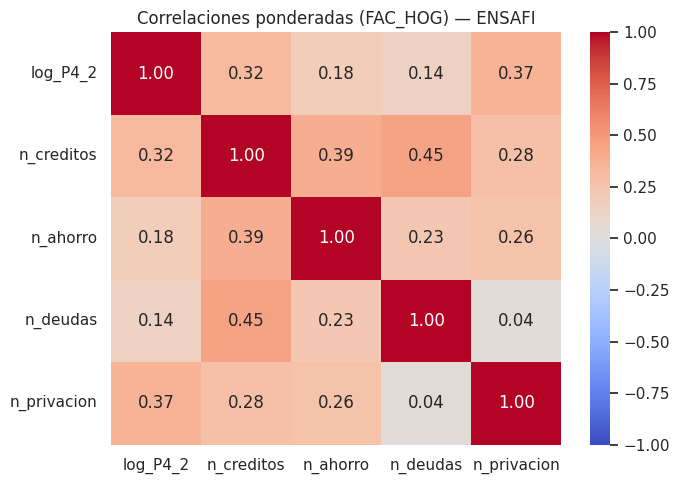

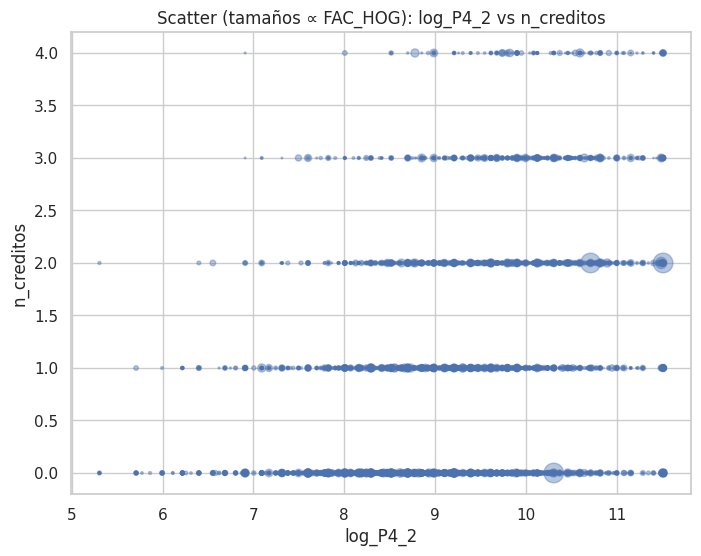

In [173]:
sns.set(style="whitegrid")

# CONFIGURACIÓN
WEIGHT_COL = 'FAC_HOG'
INCOME_COL = 'P4_2'
P4_5_COLS = ['P4_5_1','P4_5_2','P4_5_3','P4_5_4']   # tenencias de crédito
P4_6_COLS = ['P4_6_1','P4_6_2','P4_6_3','P4_6_4','P4_6_5']  # modalidades ahorro
P4_7_COLS = ['P4_7_1','P4_7_2','P4_7_3','P4_7_4']   # tipos deuda
P4_10_COLS = ['P4_10_1', 'P4_10_2', 'P4_10_3', 'P4_10_4', 'P4_10_5', 'P4_10_6']

# Parámetros de la visualización
N_SAMPLE_PLOT = 2000   # tamaño de la muestra para el pairplot
RANDOM_SEED = 2025

# Preprocesamiento
# (Asegurar columnas numéricas)
dfTH[WEIGHT_COL] = pd.to_numeric(dfTH[WEIGHT_COL], errors='coerce')
dfTH[INCOME_COL] = pd.to_numeric(dfTH[INCOME_COL], errors='coerce')

for c in P4_5_COLS + P4_6_COLS + P4_7_COLS + P4_10_COLS:
    if c in dfTH.columns:
        dfTH[c] = pd.to_numeric(dfTH[c], errors='coerce')

# Crear variables derivadas: conteos por hogar (número de "Sí" en subítems)
dfTH['n_creditos'] = dfTH.loc[:, [c for c in P4_5_COLS if c in dfTH.columns]].eq(1).sum(axis=1)
dfTH['n_ahorro']  = dfTH.loc[:, [c for c in P4_6_COLS if c in dfTH.columns]].eq(1).sum(axis=1)
dfTH['n_deudas']  = dfTH.loc[:, [c for c in P4_7_COLS if c in dfTH.columns]].eq(1).sum(axis=1)
dfTH['n_privacion']  = dfTH.loc[:, [c for c in P4_10_COLS if c in dfTH.columns]].eq(1).sum(axis=1)

# Transformación útil: log(ingreso + 1) para suavizar cola derecha
dfTH['log_P4_2'] = np.log1p(dfTH[INCOME_COL])

# Filtrado mínimo: eliminar filas sin peso válido
dfTH_clean = dfTH[dfTH[WEIGHT_COL].notna() & (dfTH[WEIGHT_COL] > 0)].copy()

# Elegir variables para pairplot
# Escoge variables numéricas (ejemplo recomendado)
vars_to_plot = ['log_P4_2', 'n_creditos', 'n_ahorro', 'n_deudas','n_privacion']

# Asegurar que existan en df
vars_to_plot = [v for v in vars_to_plot if v in dfTH_clean.columns]
print("Variables a graficar:", vars_to_plot)

# Pairplot simple (submuestra aleatoria sin ponderar)
# (útil para exploración rápida; NO incorpora FAC_HOG)
#sample_simple = dfTH_clean.sample(n=min(N_SAMPLE_PLOT, len(dfTH_clean)), random_state=RANDOM_SEED)
#g = sns.pairplot(sample_simple[vars_to_plot], diag_kind='kde', plot_kws={'alpha':0.5, 's':20})
#g.fig.suptitle("Pairplot (submuestra simple) — ENSAFI", y=1.02)
#plt.show()

# Pairplot mediante resampleo ponderado
# Muestreo con reemplazo con probabilidad proporcional al peso
weights = dfTH_clean[WEIGHT_COL].fillna(0).values
probs = weights / weights.sum()
n_plot = min(N_SAMPLE_PLOT, len(dfTH_clean))
rng = np.random.RandomState(RANDOM_SEED)
idx = rng.choice(dfTH_clean.index.values, size=n_plot, replace=True, p=probs)
resampled = dfTH_clean.loc[idx].reset_index(drop=True)

g2 = sns.pairplot(resampled[vars_to_plot], diag_kind='kde', plot_kws={'alpha':0.5, 's':20})
g2.fig.suptitle("Pairplot ponderado por factor de expansión FAC_HOG) — ENSAFI", y=1.02)
plt.show()

# Matriz de correlaciones ponderadas
def weighted_mean(x, w):
    mask = (~x.isna()) & (~w.isna())
    x_, w_ = x[mask], w[mask]
    return (x_*w_).sum()/w_.sum() if w_.sum()>0 else np.nan

def weighted_cov(x, y, w):
    mask = (~x.isna()) & (~y.isna()) & (~w.isna())
    x_, y_, w_ = x[mask], y[mask], w[mask]
    if w_.sum() == 0:
        return np.nan
    mx = (x_*w_).sum()/w_.sum()
    my = (y_*w_).sum()/w_.sum()
    return (w_ * (x_-mx) * (y_-my)).sum() / w_.sum()

def weighted_var(x, w):
    return weighted_cov(x, x, w)

def weighted_corr_matrix(df, variables, weight_col=WEIGHT_COL):
    w = df[weight_col]
    mat = pd.DataFrame(index=variables, columns=variables, dtype=float)
    for i, vi in enumerate(variables):
        for j, vj in enumerate(variables):
            cov = weighted_cov(df[vi], df[vj], w)
            var_i = weighted_var(df[vi], w)
            var_j = weighted_var(df[vj], w)
            mat.loc[vi, vj] = cov / np.sqrt(var_i*var_j) if (var_i>0 and var_j>0) else np.nan
    return mat

w_corr = weighted_corr_matrix(dfTH_clean, vars_to_plot, WEIGHT_COL)
print("\nMatriz de correlación ponderada (FAC_HOG):\n", w_corr)

# Heatmap para la matriz ponderada
plt.figure(figsize=(7,5))
sns.heatmap(w_corr.astype(float), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlaciones ponderadas (FAC_HOG) — ENSAFI")
plt.tight_layout()
plt.show()

# Alternativa: scatter con tamaño proporcional al peso
# (visualizar relación entre 2 variables con influencia del peso)
if len(vars_to_plot) >= 2:
    xvar, yvar = vars_to_plot[0], vars_to_plot[1]
    sample_scatter = dfTH_clean[[xvar, yvar, WEIGHT_COL]].dropna()
    # Normalizar tamaños para plotting
    sizes = (sample_scatter[WEIGHT_COL] / sample_scatter[WEIGHT_COL].max()) * 200
    plt.figure(figsize=(8,6))
    plt.scatter(sample_scatter[xvar], sample_scatter[yvar], s=sizes, alpha=0.4)
    plt.xlabel(xvar); plt.ylabel(yvar)
    plt.title(f"Scatter (tamaños ∝ FAC_HOG): {xvar} vs {yvar}")
    plt.show()


## HEATMAP - TENENCIA DE CRÉDITO (de banco) VS CONDICIÓN DE DEUDA (tarjeta de crédito)
Observamos que la población que tiene tarjeta de credito de banco P4_5_2, el 56.6 % de las personas tiene una deuda de tarjeta de credito, de institución financiera o de tienda departamental

Tabla ponderada (suma de pesos):


P4_7_1,No,No sabe,Sí
P4_5_2,,,
No,20583044,81693,4582962
No sabe,89902,9737,22066
Sí,3281449,25847,4311455


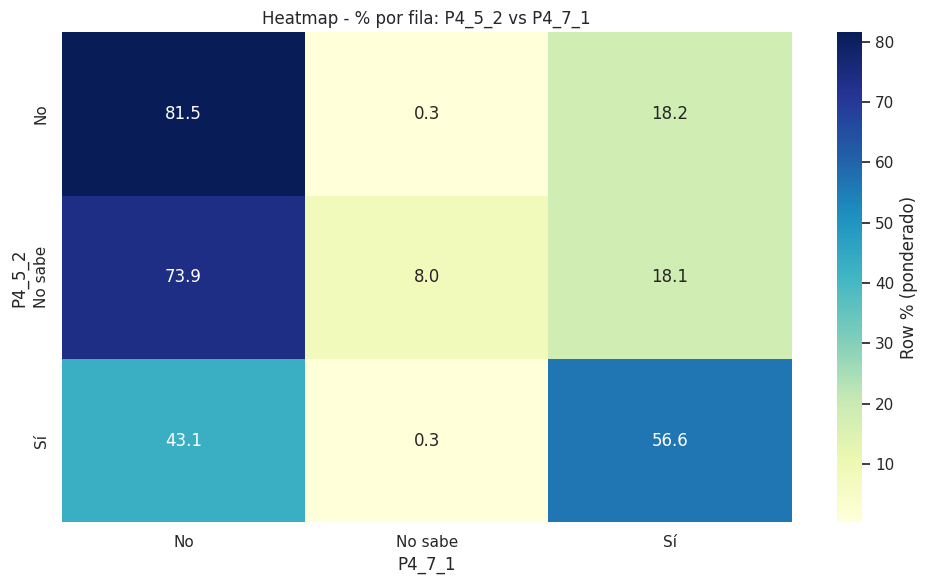

In [179]:

sns.set(style="whitegrid")

# CONFIGURACIÓN
df = dfTH  # DataFrame
WEIGHT = "FAC_HOG"   # columna de peso
var_x = "P4_5_2"     # Variable categórica Tenencia de Crédito
var_y = "P4_7_1"        # Variable categórica Condición de deuda
INCLUDE_DK = True    # incluir "No sabe" si existe (código 9)
YES, NO, DK = 1, 2, 9

# Preprocesamiento
# Asegurar numerico en peso y filtrar filas sin peso valido
df[WEIGHT] = pd.to_numeric(df[WEIGHT], errors="coerce")
df = df[df[WEIGHT].notna() & (df[WEIGHT] > 0)].copy()

# Convertir variables a categoría y rellenar NaN si quieres un grupo "Missing"
for v in [var_x, var_y]:
    if v not in df.columns:
        raise ValueError(f"Variable {v} no encontrada en df")
    df[v] = df[v].astype('Int64')  # permite NA y enteros
    # Mantener códigos especiales (p ej. 9), o mapear a string:
    #df[v] = df[v].astype(object).where(df[v].notna(), other="(Missing)")
    # Opcional: map numeric codes a etiquetas (si tienes diccionario)
    label_map = {1:'Sí', 2:'No', 9:'No sabe'}; df[v] = df[v].map(label_map).fillna(df[v])

# Tabla de contingencia ponderada
# Groupby sum of weights
cont = df.groupby([var_x, var_y])[WEIGHT].sum().unstack(fill_value=0)
# cont is weighted counts (suma de FAC_HOG)
print("Tabla ponderada (suma de pesos):")
display(cont)

# Normalizaciones y porcentajes
total = cont.values.sum()         # universo expandido
row_totals = cont.sum(axis=1)     # suma por fila (var_x)
col_totals = cont.sum(axis=0)     # suma por columna (var_y)

# Overall % (cada celda / total)
pct_overall = cont / total * 100

# Row % (cada celda / fila)
pct_row = cont.div(row_totals, axis=0) * 100

# Col % (cada celda / columna)
pct_col = cont.div(col_totals, axis=1) * 100

# Heatmap: Row % (por fila)
plt.figure(figsize=(10,6))
ax = sns.heatmap(pct_row, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Row % (ponderado)'})
ax.set_title(f"Heatmap - % por fila: {var_x} vs {var_y}")
ax.set_xlabel(var_y); ax.set_ylabel(var_x)
plt.tight_layout()
plt.show()



## HEATMAP - TENENCIA DE CRÉDITO (automotriz) VS CONDICIÓN DE DEUDA (tarjeta de credito)
Observamos que la población que tiene crédito automotriz P4_5_3, el 61.1 % de las personas tiene una deuda de tarjeta de credito, de institución financiera o de tienda departamental

Tabla ponderada (suma de pesos):


P4_7_1,No,No sabe,Sí
P4_5_3,,,
No,23391309,104194,8107650
No sabe,63563,9441,18403
Sí,499523,3642,790430


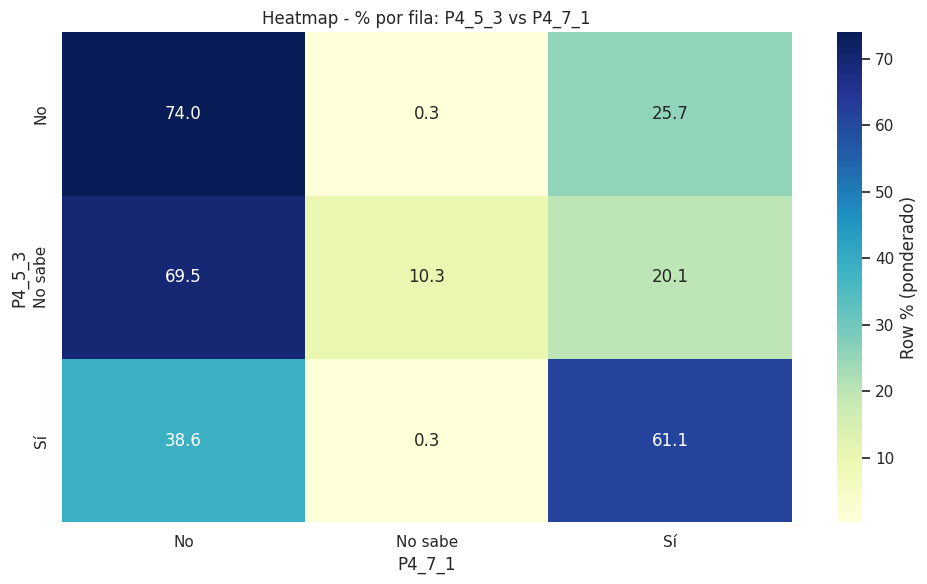

In [181]:
sns.set(style="whitegrid")

# CONFIGURACIÓN
df = dfTH  # DataFrame
WEIGHT = "FAC_HOG"   # columna de peso
var_x = "P4_5_3"     # Variable categórica Tenencia de Crédito
var_y = "P4_7_1"        # Variable categórica Condición de deuda
INCLUDE_DK = True    # incluir "No sabe" si existe (código 9)
YES, NO, DK = 1, 2, 9

# Preprocesamiento
# Asegurar numerico en peso y filtrar filas sin peso valido
df[WEIGHT] = pd.to_numeric(df[WEIGHT], errors="coerce")
df = df[df[WEIGHT].notna() & (df[WEIGHT] > 0)].copy()

# Convertir variables a categoría y rellenar NaN si quieres un grupo "Missing"
for v in [var_x, var_y]:
    if v not in df.columns:
        raise ValueError(f"Variable {v} no encontrada en df")
    df[v] = df[v].astype('Int64')  # permite NA y enteros
    # Mantener códigos especiales (p ej. 9), o mapear a string:
    #df[v] = df[v].astype(object).where(df[v].notna(), other="(Missing)")
    # Opcional: map numeric codes a etiquetas (si tienes diccionario)
    label_map = {1:'Sí', 2:'No', 9:'No sabe'}; df[v] = df[v].map(label_map).fillna(df[v])

# Tabla de contingencia ponderada
# Groupby sum of weights
cont = df.groupby([var_x, var_y])[WEIGHT].sum().unstack(fill_value=0)
# cont is weighted counts (suma de FAC_HOG)
print("Tabla ponderada (suma de pesos):")
display(cont)

# Normalizaciones y porcentajes
total = cont.values.sum()         # universo expandido
row_totals = cont.sum(axis=1)     # suma por fila (var_x)
col_totals = cont.sum(axis=0)     # suma por columna (var_y)

# Overall % (cada celda / total)
pct_overall = cont / total * 100

# Row % (cada celda / fila)
pct_row = cont.div(row_totals, axis=0) * 100

# Col % (cada celda / columna)
pct_col = cont.div(col_totals, axis=1) * 100

# Heatmap: Row % (por fila)
plt.figure(figsize=(10,6))
ax = sns.heatmap(pct_row, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Row % (ponderado)'})
ax.set_title(f"Heatmap - % por fila: {var_x} vs {var_y}")
ax.set_xlabel(var_y); ax.set_ylabel(var_x)
plt.tight_layout()
plt.show()

## HEATMAP - TENENCIA DE CRÉDITO (de banco) VS CONDICIÓN DE HÁBITOS DE AHORRO (ahorro en cuenta de banco)
Observamos que la población que tiene tarjeta de crédito de banco P4_5_2, el 43.4 % de las personas acostumbra ahorrar en una cuenta de banco o de institución financiera

Tabla ponderada (suma de pesos):


P4_6_1,No,No sabe,Sí
P4_5_2,,,
No,22127036,65606,3055057
No sabe,63352,35858,22495
Sí,4266888,46144,3305719


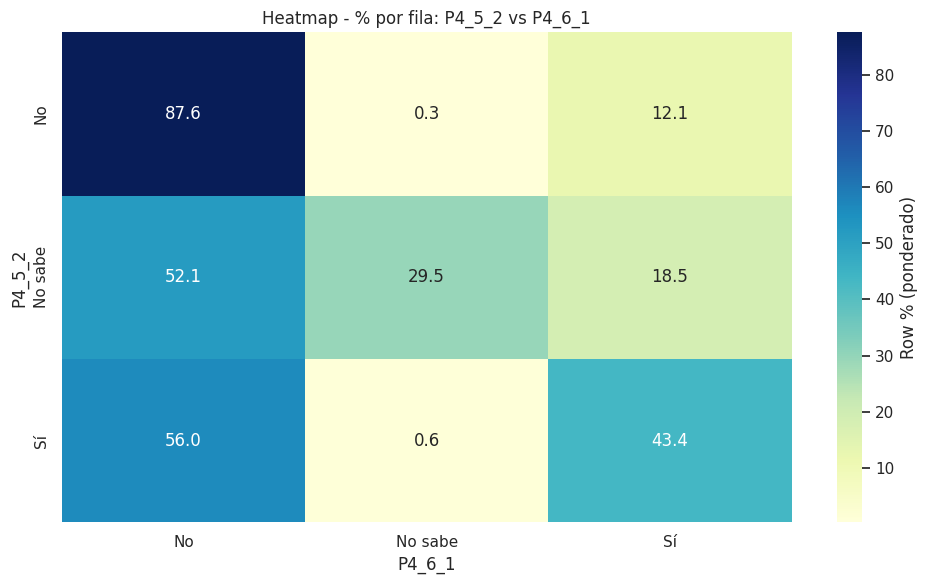

In [182]:
sns.set(style="whitegrid")

# CONFIGURACIÓN
df = dfTH  # DataFrame
WEIGHT = "FAC_HOG"   # columna de peso
var_x = "P4_5_2"     # Variable categórica Tenencia de Crédito
var_y = "P4_6_1"        # Variable categórica Condición de deuda
INCLUDE_DK = True    # incluir "No sabe" si existe (código 9)
YES, NO, DK = 1, 2, 9

# Preprocesamiento
# Asegurar numerico en peso y filtrar filas sin peso valido
df[WEIGHT] = pd.to_numeric(df[WEIGHT], errors="coerce")
df = df[df[WEIGHT].notna() & (df[WEIGHT] > 0)].copy()

# Convertir variables a categoría y rellenar NaN si quieres un grupo "Missing"
for v in [var_x, var_y]:
    if v not in df.columns:
        raise ValueError(f"Variable {v} no encontrada en df")
    df[v] = df[v].astype('Int64')  # permite NA y enteros
    # Mantener códigos especiales (p ej. 9), o mapear a string:
    #df[v] = df[v].astype(object).where(df[v].notna(), other="(Missing)")
    # Opcional: map numeric codes a etiquetas (si tienes diccionario)
    label_map = {1:'Sí', 2:'No', 9:'No sabe'}; df[v] = df[v].map(label_map).fillna(df[v])

# Tabla de contingencia ponderada
# Groupby sum of weights
cont = df.groupby([var_x, var_y])[WEIGHT].sum().unstack(fill_value=0)
# cont is weighted counts (suma de FAC_HOG)
print("Tabla ponderada (suma de pesos):")
display(cont)

# Normalizaciones y porcentajes
total = cont.values.sum()         # universo expandido
row_totals = cont.sum(axis=1)     # suma por fila (var_x)
col_totals = cont.sum(axis=0)     # suma por columna (var_y)

# Overall % (cada celda / total)
pct_overall = cont / total * 100

# Row % (cada celda / fila)
pct_row = cont.div(row_totals, axis=0) * 100

# Col % (cada celda / columna)
pct_col = cont.div(col_totals, axis=1) * 100

# Heatmap: Row % (por fila)
plt.figure(figsize=(10,6))
ax = sns.heatmap(pct_row, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Row % (ponderado)'})
ax.set_title(f"Heatmap - % por fila: {var_x} vs {var_y}")
ax.set_xlabel(var_y); ax.set_ylabel(var_x)
plt.tight_layout()
plt.show()

## HEATMAP - CONDICIÓN DE DEUDA (deuda en tarjeta de crédito) VS PRIVACIÓN ECONÓMICA (darle mantenimiento a la casa o pagar renta o crédito de vivienda)
Observamos que la población que tiene deuda tarjeta de crédito de banco P4_7_1, el 36.2 % de las personas no tuvo suficiente dinero para darle mantenimiento a la casa o pagar renta o crédito de vivienda

Tabla ponderada (suma de pesos):


P4_10_2,No,No sabe,Sí
P4_7_1,,,
No,10015673,15408,13923314
No sabe,46245,1346,69686
Sí,3227324,4342,5684817


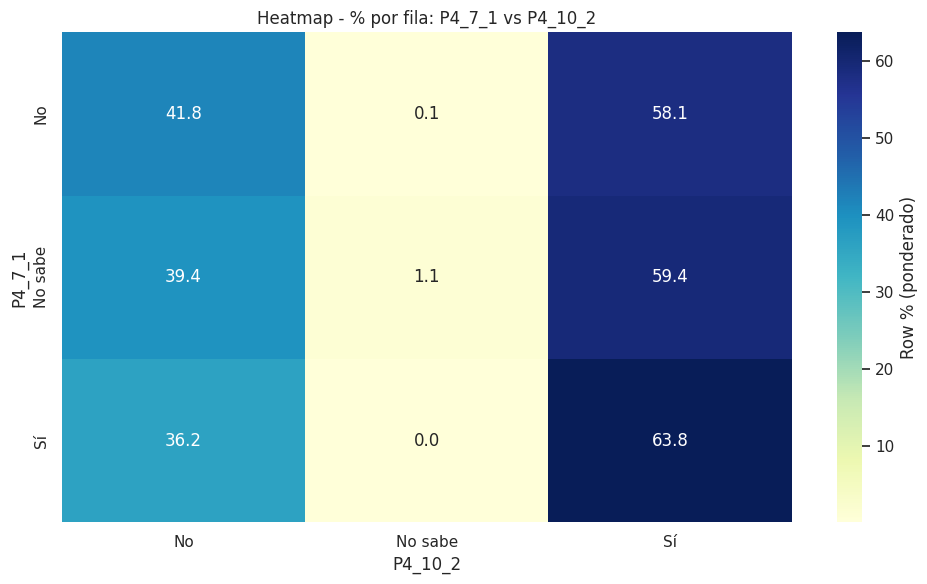

In [185]:
sns.set(style="whitegrid")

# CONFIGURACIÓN
df = dfTH  # DataFrame
WEIGHT = "FAC_HOG"   # columna de peso
var_x = "P4_7_1"     # Variable categórica Tenencia de Crédito
var_y = "P4_10_2"        # Variable categórica Condición de deuda
INCLUDE_DK = True    # incluir "No sabe" si existe (código 9)
YES, NO, DK = 1, 2, 9

# Preprocesamiento
# Asegurar numerico en peso y filtrar filas sin peso valido
df[WEIGHT] = pd.to_numeric(df[WEIGHT], errors="coerce")
df = df[df[WEIGHT].notna() & (df[WEIGHT] > 0)].copy()

# Convertir variables a categoría y rellenar NaN si quieres un grupo "Missing"
for v in [var_x, var_y]:
    if v not in df.columns:
        raise ValueError(f"Variable {v} no encontrada en df")
    df[v] = df[v].astype('Int64')  # permite NA y enteros
    # Mantener códigos especiales (p ej. 9), o mapear a string:
    #df[v] = df[v].astype(object).where(df[v].notna(), other="(Missing)")
    # Opcional: map numeric codes a etiquetas (si tienes diccionario)
    label_map = {1:'Sí', 2:'No', 9:'No sabe'}; df[v] = df[v].map(label_map).fillna(df[v])

# Tabla de contingencia ponderada
# Groupby sum of weights
cont = df.groupby([var_x, var_y])[WEIGHT].sum().unstack(fill_value=0)
# cont is weighted counts (suma de FAC_HOG)
print("Tabla ponderada (suma de pesos):")
display(cont)

# Normalizaciones y porcentajes
total = cont.values.sum()         # universo expandido
row_totals = cont.sum(axis=1)     # suma por fila (var_x)
col_totals = cont.sum(axis=0)     # suma por columna (var_y)

# Overall % (cada celda / total)
pct_overall = cont / total * 100

# Row % (cada celda / fila)
pct_row = cont.div(row_totals, axis=0) * 100

# Col % (cada celda / columna)
pct_col = cont.div(col_totals, axis=1) * 100

# Heatmap: Row % (por fila)
plt.figure(figsize=(10,6))
ax = sns.heatmap(pct_row, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Row % (ponderado)'})
ax.set_title(f"Heatmap - % por fila: {var_x} vs {var_y}")
ax.set_xlabel(var_y); ax.set_ylabel(var_x)
plt.tight_layout()
plt.show()

### Distribución ponderada del ingreso mensual del hogar
Podemos observar que la media es mayor a la mediana dado que los ingresos altos incrementan la media, tenemos una distribución sesgada a la derecha, los hogares se concentran a la izquierda con ingresos muensuales bajos.

Concluimos que no se presenta una distribución normal para el caso de los ingresos mensuales en los hogares, por lo cual habrá que determinar cuales transformaciones nos convienen para los análisis posteriores

Tamaño efectivo de muestra: 20,448
Universo expandido: 38,669,271 hogares
Media ponderada: $18,811.36
Mediana ponderada: $8,300.00
Desviación estándar ponderada: $26,730.54
Asimetría (skewness): 2.44
Curtosis: 4.78


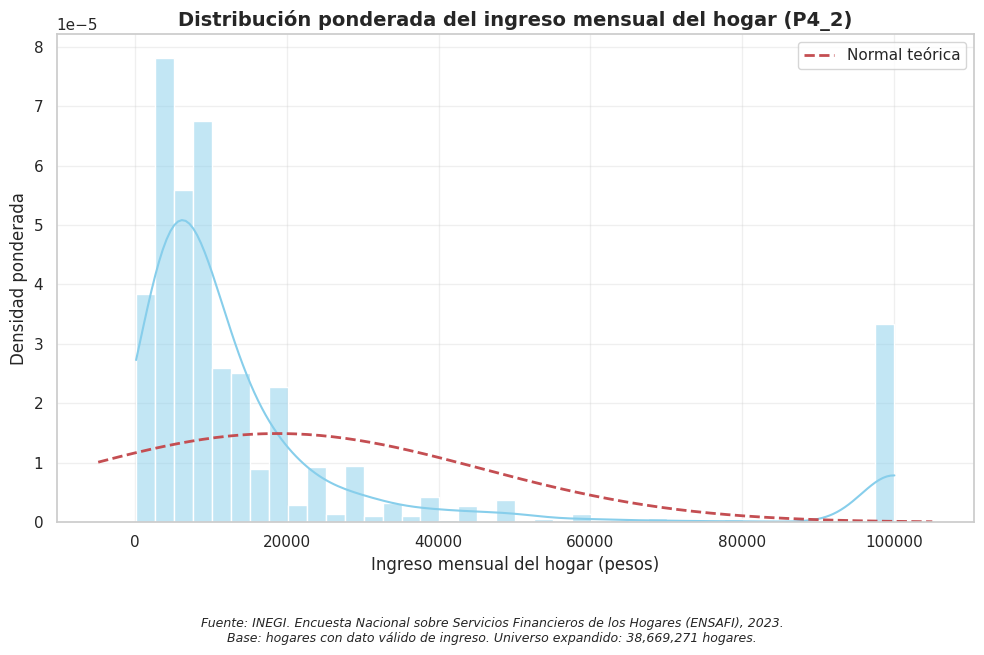

In [196]:
# CONFIGURACIÓN
# ----------------------------------------------------------------
VAR = "P4_2"       # Ingreso mensual del hogar
W = "FAC_HOG"      # Ponderador
df = dfTH.copy()

# DEPURACIÓN Y VALIDACIÓN

# Convertir a numérico
df[VAR] = pd.to_numeric(df[VAR], errors="coerce")
df[W] = pd.to_numeric(df[W], errors="coerce")

# Filtrar valores válidos de peso
df = df[df[W].notna() & (df[W] > 0)]

# Eliminar valores especiales o top-coded (según diseño ENSAFI)
# Ejemplo: 98000 = “98,000 y más”, 99999 = “No sabe”
#df = df[~df[VAR].isin([98000, 99999, 99998])].copy()

# Filtrar valores extremos negativos o nulos
df = df[df[VAR] > 0].copy()

print(f"Tamaño efectivo de muestra: {len(df):,}")
print(f"Universo expandido: {df[W].sum():,.0f} hogares")

# MEDIDAS DESCRIPTIVAS PONDERADAS
x = df[VAR]
w = df[W]

# Media ponderada
mean_w = np.average(x, weights=w)

# Varianza y desviación estándar ponderada
var_w = np.average((x - mean_w)**2, weights=w)
std_w = np.sqrt(var_w)

# Mediana ponderada (requiere ordenamiento acumulado)
df_sorted = df.sort_values(VAR)
cum_weights = df_sorted[W].cumsum()
cutoff = df_sorted[W].sum() / 2
median_w = df_sorted.loc[cum_weights >= cutoff, VAR].iloc[0]

# Asimetría y curtosis ponderadas (aproximación sin pesos)
skew_w = skew(x)
kurt_w = kurtosis(x)

print(f"Media ponderada: ${mean_w:,.2f}")
print(f"Mediana ponderada: ${median_w:,.2f}")
print(f"Desviación estándar ponderada: ${std_w:,.2f}")
print(f"Asimetría (skewness): {skew_w:.2f}")
print(f"Curtosis: {kurt_w:.2f}")

# VISUALIZACIÓN DE LA DISTRIBUCIÓN PONDERADA

sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
sns.histplot(df, x=VAR, weights=W, bins=40, kde=True, color="skyblue", stat="density")

# Curva normal teórica con misma media y desviación estándar
xmin, xmax = plt.xlim()
xvals = np.linspace(xmin, xmax, 200)
plt.plot(xvals, norm.pdf(xvals, mean_w, std_w), 'r--', lw=2, label="Normal teórica")

plt.title("Distribución ponderada del ingreso mensual del hogar (P4_2)", fontsize=14, weight='bold')
plt.xlabel("Ingreso mensual del hogar (pesos)", fontsize=12)
plt.ylabel("Densidad ponderada", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)


# Footer
plt.figtext(0.5, -0.08,
             "Fuente: INEGI. Encuesta Nacional sobre Servicios Financieros de los Hogares (ENSAFI), 2023.\n"
             f"Base: hogares con dato válido de ingreso. Universo expandido: {df[W].sum():,.0f} hogares.",
             ha="center", fontsize=9, style="italic", wrap=True)

plt.tight_layout()
plt.show()
